# Analisis de resultados

Este notebook consume los datos generados por `generador_de_datos.ipynb` y organiza la parte analitica de la entrega.

En esta etapa el flujo experimental activo corresponde a `gradiente`, y los datos se leen desde:

- `gradiente/datos/<funcion>/`

La idea es que este notebook concentre:
- presentacion del analisis
- carga general de datos
- visualizacion de funciones matematicas
- resultados experimentales
- figuras y tablas para el reporte
- mas adelante, animaciones finales


## 1. Presentacion del notebook

Este notebook esta pensado para crecer por bloques, pero con una estructura estable para las 6 funciones del proyecto:

- Rosenbrock
- Schwefel
- Rastrigin
- Griewank
- Goldstein-Price
- Six-Hump Camel

Notas metodologicas:
- por ahora el analisis experimental activo corresponde a gradiente
- `Goldstein-Price` y `Six-Hump Camel` se visualizan en 2D porque en el proyecto se manejan en su forma clasica bidimensional
- las formulas matematicas y gradientes ya quedaron documentados en `reporte_estructura.md`, asi que aqui no se duplican como teoria extensa; se usan como apoyo a la visualizacion


In [74]:
import ast
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_DIR = Path.cwd()
PROJECT_DIR = BASE_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))

from funciones_objetivo import (
    goldstein_price,
    griewank,
    rastrigin,
    rosenbrock,
    schwefel,
    six_hump_camel,
)

from report_utils import add_run_count_from_filename, build_summary_table, prepare_function_runs, save_figure
from plot_utils import (
    plot_function_course_style,
    plot_rosenbrock_evaluations_histogram,
    plot_rosenbrock_final_value_histogram,
)

DATA_DIR = BASE_DIR / "datos"
FIGURES_DIR = DATA_DIR / "figuras"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = DATA_DIR / "manifest_gradiente.json"
REPORTE_PATH = PROJECT_DIR / "reporte_estructura.md"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "No se encontro la carpeta datos dentro de gradiente. Ejecuta primero generador_de_datos.ipynb."
    )

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(
        "No se encontro manifest_gradiente.json. Ejecuta primero generador_de_datos.ipynb."
    )

if not REPORTE_PATH.exists():
    raise FileNotFoundError(
        "No se encontro reporte_estructura.md."
    )


## 2. Carga general de datos

En esta seccion se cargan las corridas disponibles y los resumenes por funcion.

La estructura esperada es:

- `datos/rosenbrock/`
- `datos/schwefel/`
- `datos/rastrigin/`
- `datos/griewank/`
- `datos/goldstein_price/`
- `datos/six_hump_camel/`


In [75]:
with MANIFEST_PATH.open("r", encoding="utf-8") as file:
    manifest = json.load(file)

manifest


{'modulo': 'gradiente',
 'funciones': ['rosenbrock',
  'schwefel',
  'rastrigin',
  'griewank',
  'goldstein_price',
  'six_hump_camel'],
 'consumer_notebook': 'analisis_resultados.ipynb',
 'descripcion': 'Datos generados sin graficas ni animaciones.',
 'filtros_ejecucion': {'selected_functions': None,
  'selected_dimensions': None,
  'selected_n_corridas': [100, 500, 1000],
  'skip_existing_files': True},
 'directorios': {'datos_base': 'gradiente/datos'},
 'organizacion_corridas': 'gradiente/datos/<funcion>/<archivo>.json|csv',
 'organizacion_resumenes': 'gradiente/datos/<funcion>/resumen_<funcion>.json|csv',
 'campos_corridas': ['funcion',
  'nombre_funcion',
  'corrida',
  'semilla',
  'metodo',
  'dimension',
  'limites',
  'posicion_inicial',
  'posicion_final',
  'valor_final',
  'iteraciones',
  'evaluaciones',
  'parametros'],
 'campos_resumen': ['funcion',
  'nombre_funcion',
  'metodo',
  'dimension',
  'n_corridas',
  'mejor_valor_final',
  'peor_valor_final',
  'promedio_va

In [76]:
run_files = sorted(path for path in DATA_DIR.glob("*/*.csv") if not path.name.startswith("resumen_"))
summary_files = sorted(DATA_DIR.glob("*/resumen_*.csv"))

if not run_files:
    raise FileNotFoundError(
        "No se encontraron archivos de corridas dentro de datos/<funcion>/."
    )

runs_df = pd.concat((pd.read_csv(path) for path in run_files), ignore_index=True)

if summary_files:
    summary_df = pd.concat((pd.read_csv(path) for path in summary_files), ignore_index=True)
else:
    summary_df = (
        runs_df.groupby(["funcion", "nombre_funcion", "metodo", "dimension"], dropna=False)
        .agg(
            n_corridas=("corrida", "count"),
            mejor_valor_final=("valor_final", "min"),
            peor_valor_final=("valor_final", "max"),
            promedio_valor_final=("valor_final", "mean"),
            mediana_valor_final=("valor_final", "median"),
            desviacion_valor_final=("valor_final", "std"),
            promedio_evaluaciones=("evaluaciones", "mean"),
            mediana_evaluaciones=("evaluaciones", "median"),
            promedio_iteraciones=("iteraciones", "mean"),
            mediana_iteraciones=("iteraciones", "median"),
        )
        .reset_index()
    )
    summary_df["desviacion_valor_final"] = summary_df["desviacion_valor_final"].fillna(0.0)


In [77]:
print("Archivos de corridas encontrados:", len(run_files))
print("Archivos de resumen encontrados:", len(summary_files))

run_files


Archivos de corridas encontrados: 36
Archivos de resumen encontrados: 6


[WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/goldstein_price/goldstein_price_gradient_2d_n100.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/goldstein_price/goldstein_price_gradient_2d_n1000.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/goldstein_price/goldstein_price_gradient_2d_n500.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/goldstein_price/tabla_reporte_goldstein_price.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/griewank/griewank_gradient_2d_n100.csv'),
 WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/griewank/griewank_gradient_2d_n1000.csv'),
 WindowsP

In [78]:
runs_df.head()


,funcion,nombre_funcion,corrida,semilla,metodo,dimension,limites,posicion_inicial,posicion_final,valor_final,...,n_corridas,mejor_valor_final,peor_valor_final,promedio_valor_final,mediana_valor_final,desviacion_valor_final,promedio_evaluaciones,mediana_evaluaciones,promedio_iteraciones,mediana_iteraciones
0,goldstein_price,Goldstein-Price,1.0,2756.0,gradient,2,"[-1.5, 1.5]","[0.46678147946520676, 1.3863374852114507]","[1.095636113004444, 0.7344185311243888]",853.389382,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,goldstein_price,Goldstein-Price,2.0,2757.0,gradient,2,"[-1.5, 1.5]","[0.5468888700906862, -0.42041417200512]","[0.595387150489611, -0.6043336975522993]",59.364599,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,goldstein_price,Goldstein-Price,3.0,2758.0,gradient,2,"[-1.5, 1.5]","[0.00658755688643109, 0.8459045906587668]","[0.13156871890721925, 0.0719738171247586]",738.169035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,goldstein_price,Goldstein-Price,4.0,2759.0,gradient,2,"[-1.5, 1.5]","[1.1866055183988569, 0.7102889485615247]","[1.181069201794776, 0.7881671724983329]",840.499984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,goldstein_price,Goldstein-Price,5.0,2760.0,gradient,2,"[-1.5, 1.5]","[1.4875368692611244, 0.611063514735644]","[1.758785629247386, 0.1730320992008717]",84.238365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
summary_df


,funcion,nombre_funcion,metodo,dimension,n_corridas,mejor_valor_final,peor_valor_final,promedio_valor_final,mediana_valor_final,desviacion_valor_final,promedio_evaluaciones,mediana_evaluaciones,promedio_iteraciones,mediana_iteraciones
0,goldstein_price,Goldstein-Price,gradient,2,100,1.049214e+01,988.649509,148.951757,62.272785,264.292727,5002.000,5002.0,5000.000,5000.0
1,goldstein_price,Goldstein-Price,gradient,2,500,1.049214e+01,989.718375,288.418848,80.679823,361.561268,5002.000,5002.0,5000.000,5000.0
2,goldstein_price,Goldstein-Price,gradient,2,1000,1.049214e+01,989.718375,328.077633,81.164395,382.519685,5002.000,5002.0,5000.000,5000.0
3,griewank,Griewank,gradient,2,100,9.844837e-09,0.046835,0.015507,0.009865,0.012164,1766.940,1787.5,1764.940,1785.5
4,griewank,Griewank,gradient,2,500,9.844837e-09,0.046835,0.020020,0.027125,0.010502,1732.034,1772.0,1730.034,1770.0
5,griewank,Griewank,gradient,2,1000,9.844837e-09,0.046835,0.020516,0.027125,0.009895,1741.053,1807.0,1739.053,1805.0
6,griewank,Griewank,gradient,3,100,7.398605e-03,0.987636,0.037499,0.025389,0.096662,2002.000,2002.0,2000.000,2000.0
7,griewank,Griewank,gradient,3,500,7.398605e-03,0.987636,0.035174,0.029585,0.044538,2002.000,2002.0,2000.000,2000.0
8,griewank,Griewank,gradient,3,1000,7.398605e-03,0.987636,0.034752,0.029587,0.032460,2002.000,2002.0,2000.000,2000.0
9,rastrigin,Rastrigin,gradient,2,100,1.989918e+00,40.792967,22.446131,24.873723,10.328634,29.040,28.0,27.040,26.0


## 3. Visualizacion de funciones matematicas

En esta seccion se dejan reunidas las 6 funciones del trabajo con una visualizacion uniforme.

Criterio de presentacion:
- la definicion matematica y el gradiente ya estan consignados en `reporte_estructura.md`
- aqui se busca apoyo visual, no repetir toda la teoria
- se reutiliza el estilo de graficacion visto en el notebook de Catalina: una vista 3D y una vista de contorno en la misma figura


In [80]:
# La funcion de visualizacion se importa desde plot_utils.py para reutilizarla
from plot_utils import plot_function_course_style


In [81]:
ACTIVE_FUNCTIONS_IN_DATA = set(runs_df["funcion"].dropna().astype(str).unique())

FUNCTION_VISUAL_CONFIGS = {
    "rosenbrock": {
        "display_name": "Rosenbrock",
        "function": rosenbrock,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-1.0, 3.0),
        "point": (1.0, 1.0),
        "active_in_data": "rosenbrock" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/rosenbrock/.",
    },
    "schwefel": {
        "display_name": "Schwefel",
        "function": schwefel,
        "x1_range": (-500.0, 500.0),
        "x2_range": (-500.0, 500.0),
        "point": (420.9687, 420.9687),
        "active_in_data": "schwefel" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/schwefel/.",
    },
    "rastrigin": {
        "display_name": "Rastrigin",
        "function": rastrigin,
        "x1_range": (-5.12, 5.12),
        "x2_range": (-5.12, 5.12),
        "point": (0.0, 0.0),
        "active_in_data": "rastrigin" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/rastrigin/.",
    },
    "griewank": {
        "display_name": "Griewank",
        "function": griewank,
        "x1_range": (-10.0, 10.0),
        "x2_range": (-10.0, 10.0),
        "point": (0.0, 0.0),
        "active_in_data": "griewank" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Activa cuando existan archivos en gradiente/datos/griewank/.",
    },
    "goldstein_price": {
        "display_name": "Goldstein-Price",
        "function": goldstein_price,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-2.0, 2.0),
        "point": (0.0, -1.0),
        "active_in_data": "goldstein_price" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Visualizacion 2D clasica. Activa cuando existan archivos en gradiente/datos/goldstein_price/.",
    },
    "six_hump_camel": {
        "display_name": "Six-Hump Camel",
        "function": six_hump_camel,
        "x1_range": (-2.0, 2.0),
        "x2_range": (-1.5, 1.5),
        "point": (0.0898, -0.7126),
        "active_in_data": "six_hump_camel" in ACTIVE_FUNCTIONS_IN_DATA,
        "notes": "Visualizacion 2D clasica. Activa cuando existan archivos en gradiente/datos/six_hump_camel/.",
    },
}

pd.DataFrame(
    [
        {
            "funcion": key,
            "nombre": value["display_name"],
            "activa_en_datos": value["active_in_data"],
            "nota": value["notes"],
        }
        for key, value in FUNCTION_VISUAL_CONFIGS.items()
    ]
)


,funcion,nombre,activa_en_datos,nota
0,rosenbrock,Rosenbrock,True,Activa cuando existan archivos en gradiente/da...
1,schwefel,Schwefel,True,Activa cuando existan archivos en gradiente/da...
2,rastrigin,Rastrigin,True,Activa cuando existan archivos en gradiente/da...
3,griewank,Griewank,True,Activa cuando existan archivos en gradiente/da...
4,goldstein_price,Goldstein-Price,True,Visualizacion 2D clasica. Activa cuando exista...
5,six_hump_camel,Six-Hump Camel,True,Visualizacion 2D clasica. Activa cuando exista...


### 3.1 Rosenbrock

La funcion de Rosenbrock se usa como caso de prueba porque presenta un valle angosto y curvo, lo que exige pasos estables y una buena alineacion del gradiente para acercarse al minimo.

En esta seccion se analiza el comportamiento del descenso por gradiente en `2D` y `3D`, comparando tres tamanos de muestra:  = 100`, `500` y `1000`.

El objetivo no es mostrar solo el mejor resultado, sino tambien la dispersion de las corridas y el costo computacional medido en evaluaciones de la funcion objetivo.


In [82]:
# La funcion de visualizacion se importa desde plot_utils.py para reutilizarla
from plot_utils import plot_function_course_style


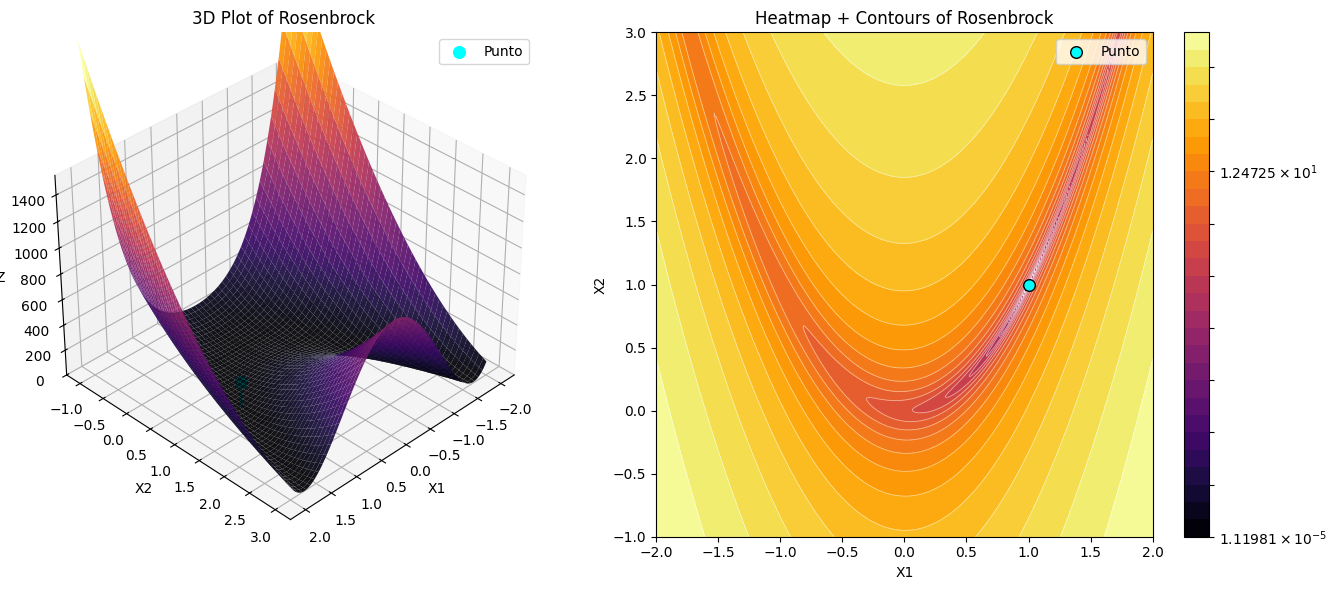

In [83]:
cfg = FUNCTION_VISUAL_CONFIGS["rosenbrock"]
plot_function_course_style(
    cfg["function"],
    cfg["x1_range"],
    cfg["x2_range"],
    title=cfg["display_name"],
    x1_point=1.0,
    x2_point=1.0,
    output_path=FIGURES_DIR / "rosenbrock_mapa_calor_y_superficie.png",
)


#### Resultados de Rosenbrock

Tomando como base `02_corridas_rosenbrock.ipynb`, aqui se consolidan las visualizaciones que mas aportan al analisis experimental sin repetir la figura de referencia de la funcion:

- histogramas de `valor_final` para medir la calidad de convergencia
- histogramas de `evaluaciones` para medir el costo computacional
- tablas resumen para contrastar estabilidad y desempeno entre tamanos de muestra

Cuando el histograma de evaluaciones se concentra en un valor casi unico, eso indica que muchas corridas alcanzaron el mismo criterio de parada, y ese comportamiento tambien forma parte del resultado.


##### Histogramas por tamano de muestra para Rosenbrock 2D

Para `Rosenbrock 2D` se presentan dos figuras complementarias: la primera resume la distribucion del `valor_final` y la segunda la distribucion del numero de `evaluaciones`, ambas separadas en  = 100`, `500` y `1000`.

En todos los histogramas, el eje `x` corresponde a la variable medida y el eje `y` a la frecuencia de corridas observada en cada intervalo.


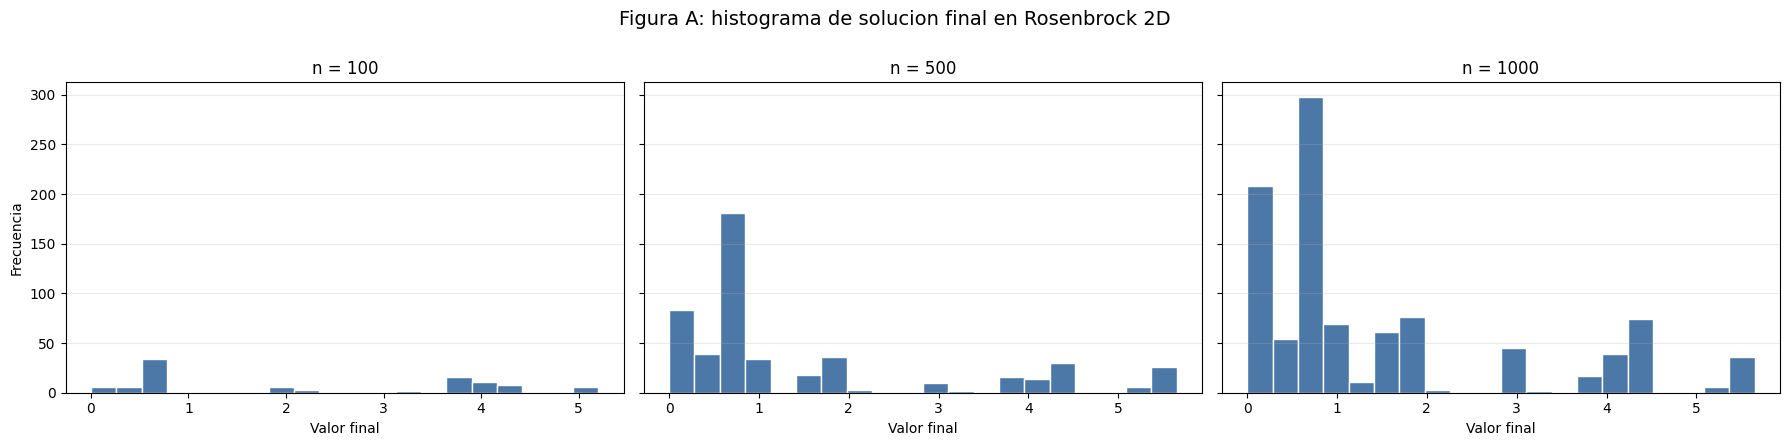

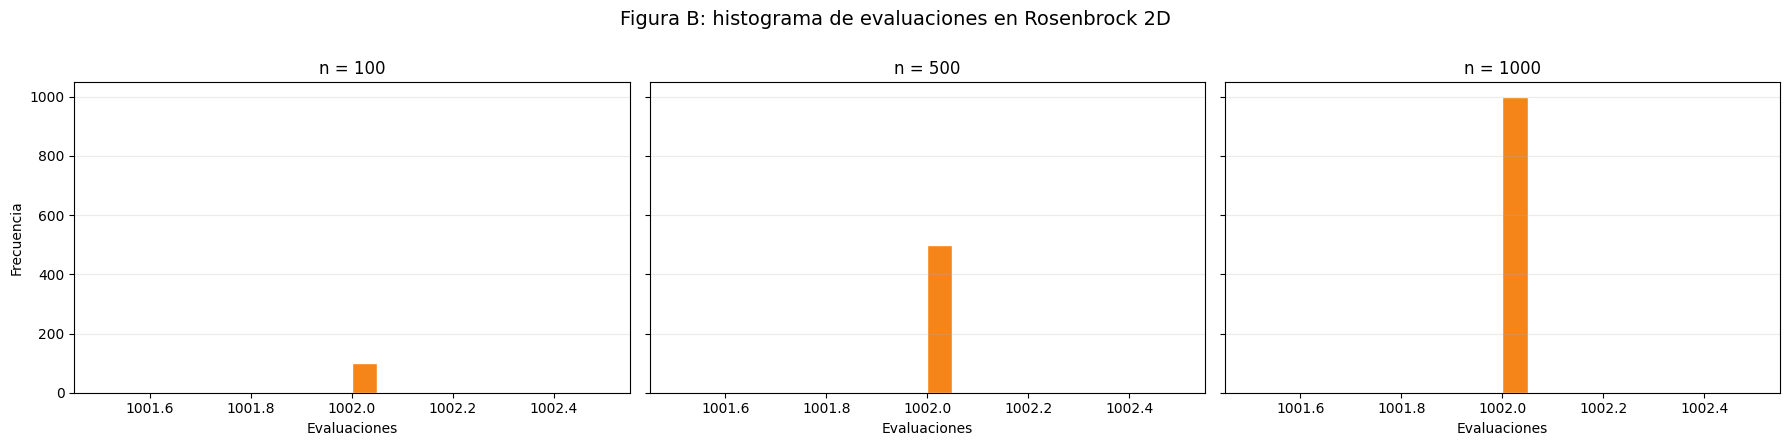

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/rosenbrock_figura_b_histograma_evaluaciones_2d.png')

In [84]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_rosenbrock_evaluations_histogram, plot_rosenbrock_final_value_histogram
from report_utils import prepare_function_runs, save_figure

rosenbrock_runs_2d = prepare_function_runs(runs_df, run_files, "rosenbrock", 2)
sample_sizes = [100, 500, 1000]
rosenbrock_figures_dir = DATA_DIR / "figuras"
rosenbrock_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a = plot_rosenbrock_final_value_histogram(
    rosenbrock_runs_2d,
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_path = rosenbrock_figures_dir / "rosenbrock_figura_a_histograma_solucion_final_2d.png"
fig_a_path = save_figure(fig_a, fig_a_path)
plt.show()
fig_a_path

fig_b = plot_rosenbrock_evaluations_histogram(
    rosenbrock_runs_2d,
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_path = rosenbrock_figures_dir / "rosenbrock_figura_b_histograma_evaluaciones_2d.png"
fig_b_path = save_figure(fig_b, fig_b_path)
plt.show()
fig_b_path


##### Histogramas por tamano de muestra para Rosenbrock 3D

Se replica el mismo formato para `Rosenbrock 3D`, de modo que la comparacion entre  = 100`, `500` y `1000` quede alineada con el caso bidimensional.

Este contraste permite verificar si el aumento de dimension introduce una mayor dificultad de convergencia o una variabilidad mas alta entre corridas.


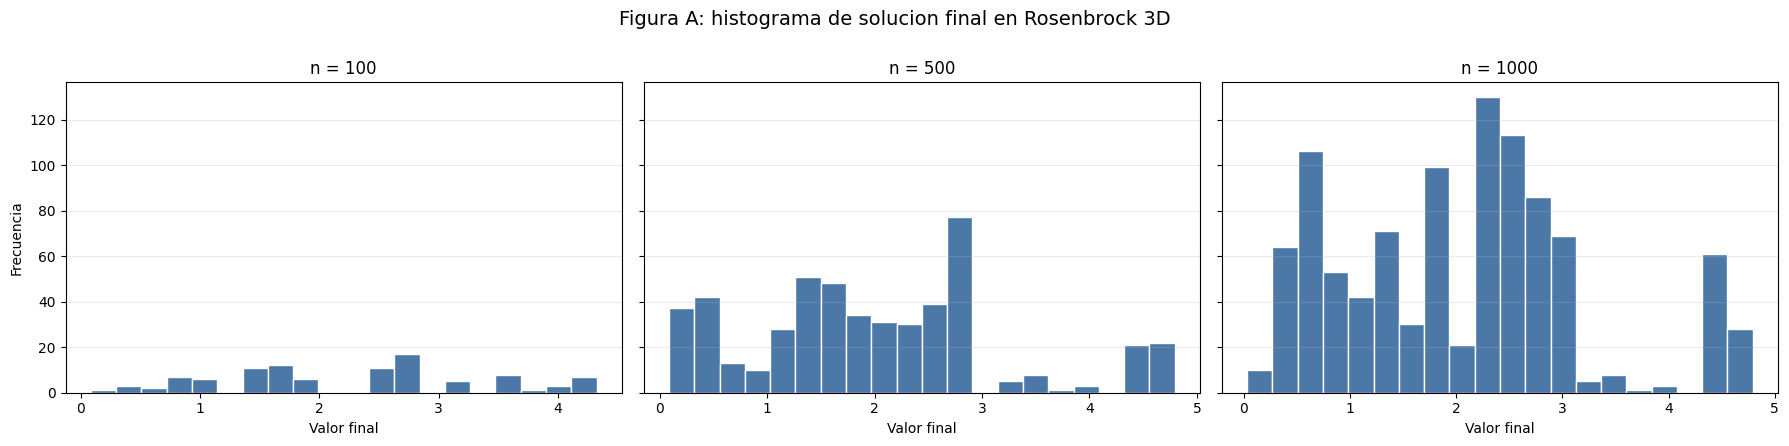

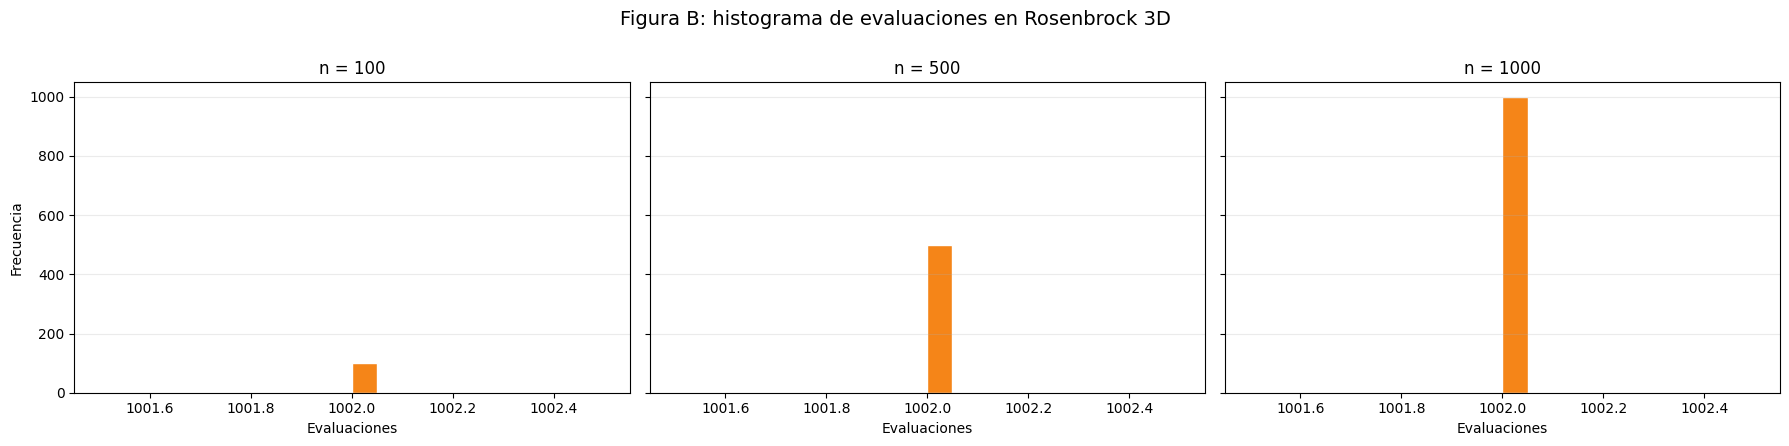

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/rosenbrock_figura_b_histograma_evaluaciones_3d.png')

In [85]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_rosenbrock_evaluations_histogram, plot_rosenbrock_final_value_histogram
from report_utils import prepare_function_runs, save_figure

rosenbrock_runs_3d = prepare_function_runs(runs_df, run_files, "rosenbrock", 3)
sample_sizes = [100, 500, 1000]
rosenbrock_figures_dir = DATA_DIR / "figuras"
rosenbrock_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_3d = plot_rosenbrock_final_value_histogram(
    rosenbrock_runs_3d,
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_a_3d_path = rosenbrock_figures_dir / "rosenbrock_figura_a_histograma_solucion_final_3d.png"
fig_a_3d_path = save_figure(fig_a_3d, fig_a_3d_path)
plt.show()
fig_a_3d_path

fig_b_3d = plot_rosenbrock_evaluations_histogram(
    rosenbrock_runs_3d,
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_b_3d_path = rosenbrock_figures_dir / "rosenbrock_figura_b_histograma_evaluaciones_3d.png"
fig_b_3d_path = save_figure(fig_b_3d, fig_b_3d_path)
plt.show()
fig_b_3d_path


##### Tabla resumen de Rosenbrock 2D

La tabla siguiente resume el comportamiento de `Rosenbrock 2D` para  = 100`, `500` y `1000`, incluyendo mejor valor, peor valor, promedio, desviacion estandar y promedio de evaluaciones.

Con esta vista compacta es posible identificar rapidamente si al aumentar el numero de corridas mejora la estabilidad de los resultados o solo se confirma la misma tendencia observada en los histogramas.


In [86]:
tabla_resumen_rosenbrock_2d = build_summary_table(summary_df, "rosenbrock", 2, dimension_label="2D")
tabla_resumen_rosenbrock_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Rosenbrock,2D,100,0.001336,5.203229,2.266506,1.711040,1002.0
1,Rosenbrock,2D,500,0.000185,5.648255,1.494395,1.645576,1002.0
2,Rosenbrock,2D,1000,0.000185,5.648255,1.490731,1.589859,1002.0


##### Tabla resumen de Rosenbrock 3D

La tabla de `Rosenbrock 3D` mantiene exactamente las mismas metricas del caso bidimensional para facilitar una comparacion directa entre ambas dimensiones.

Asi se puede evaluar si la dimension adicional incrementa la dispersion de los valores finales, empeora el mejor caso observado o mantiene un costo medio similar en evaluaciones.


In [87]:
tabla_resumen_rosenbrock_3d = build_summary_table(summary_df, "rosenbrock", 3, dimension_label="3D")
tabla_resumen_rosenbrock_3d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Rosenbrock,3D,100,0.086961,4.324086,2.263876,1.099447,1002.0
1,Rosenbrock,3D,500,0.086961,4.792868,2.022777,1.169810,1002.0
2,Rosenbrock,3D,1000,0.031785,4.792868,2.029339,1.171553,1002.0


##### Interpretacion de resultados para Rosenbrock

En terminos generales, el descenso por gradiente **si converge de manera util** en la funcion de `Rosenbrock`, pero no lo hace de forma plenamente consistente en todas las corridas. En `2D` se observan soluciones muy cercanas al optimo en el mejor caso (`0.001336` para  = 100` y `0.000185` para  = 500` y `1000`), mientras que en `3D` el mejor valor sigue siendo bueno pero menos preciso (`0.086961` y luego `0.031785`). Esto sugiere que el algoritmo encuentra zonas cercanas al minimo, aunque la dificultad aumenta cuando se agrega una dimension adicional.

La dispersion de resultados no es despreciable. En `2D` los promedios bajan de `2.266506` a aproximadamente `1.49`, pero todavia coexisten corridas muy buenas con otras claramente alejadas del optimo, como lo muestran los peores valores alrededor de `5.20` y `5.65`. En `3D` el promedio tambien mejora frente a  = 100`, pero permanece cerca de `2.02`, lo que indica que el metodo sigue teniendo sensibilidad al punto inicial. Aun asi, la desviacion estandar en `3D` (`1.10` a `1.17`) es menor que en `2D` (`1.59` a `1.71`), por lo que la dispersion parece algo mas contenida, aunque alrededor de valores finales peores.

Respecto al costo computacional, el comportamiento es alto pero muy estable: el promedio de evaluaciones es `1002.0` en todos los escenarios de `2D` y `3D`. Eso indica que, en la practica, casi todas las corridas llegan al mismo criterio de parada, probablemente asociado al limite de iteraciones configurado, mas que a una convergencia temprana muy marcada. Por eso, al aumentar el numero de corridas de `100` a `500` y `1000`, no cambia el costo por corrida, pero si se estabilizan mejor las metricas agregadas. En conjunto, `Rosenbrock 2D` muestra mejores soluciones finales que `Rosenbrock 3D`, mientras que `3D` presenta un comportamiento algo mas uniforme pero menos cercano al optimo global.


### 3.2 Schwefel

La funcion de Schwefel se incorpora como un caso mas irregular y exigente para el descenso por gradiente, ya que combina regiones alejadas del optimo con una topografia menos amigable que Rosenbrock.

En esta seccion se comparan las corridas en `2D` y `3D` para  = 100`, `500` y `1000`, manteniendo el mismo formato de presentacion del reporte.


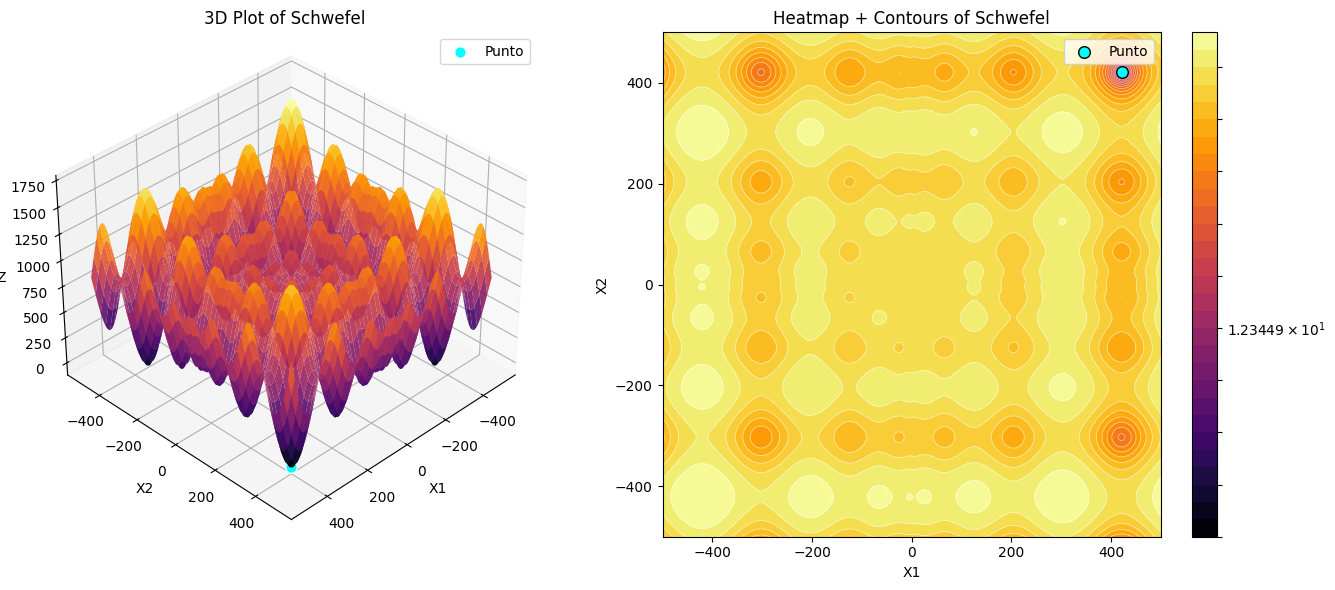

In [88]:
cfg = FUNCTION_VISUAL_CONFIGS["schwefel"]
plot_function_course_style(
    cfg["function"],
    cfg["x1_range"],
    cfg["x2_range"],
    title=cfg["display_name"],
    x1_point=cfg["point"][0],
    x2_point=cfg["point"][1],
    output_path=FIGURES_DIR / "schwefel_mapa_calor_y_superficie.png",
)


#### Resultados de Schwefel

A continuacion se organiza el analisis experimental de Schwefel con el mismo esquema usado en Rosenbrock, separando calidad de solucion, costo computacional y tablas resumen.

- histogramas de `valor_final` para medir cercania al optimo
- histogramas de `evaluaciones` para medir costo computacional
- tablas resumen para comparar comportamiento entre tamanos de muestra


##### Histogramas por tamano de muestra para Schwefel 2D

Para `Schwefel 2D` se muestran histogramas de `valor_final` y `evaluaciones` para  = 100`, `500` y `1000`, manteniendo el mismo criterio visual del resto del reporte.


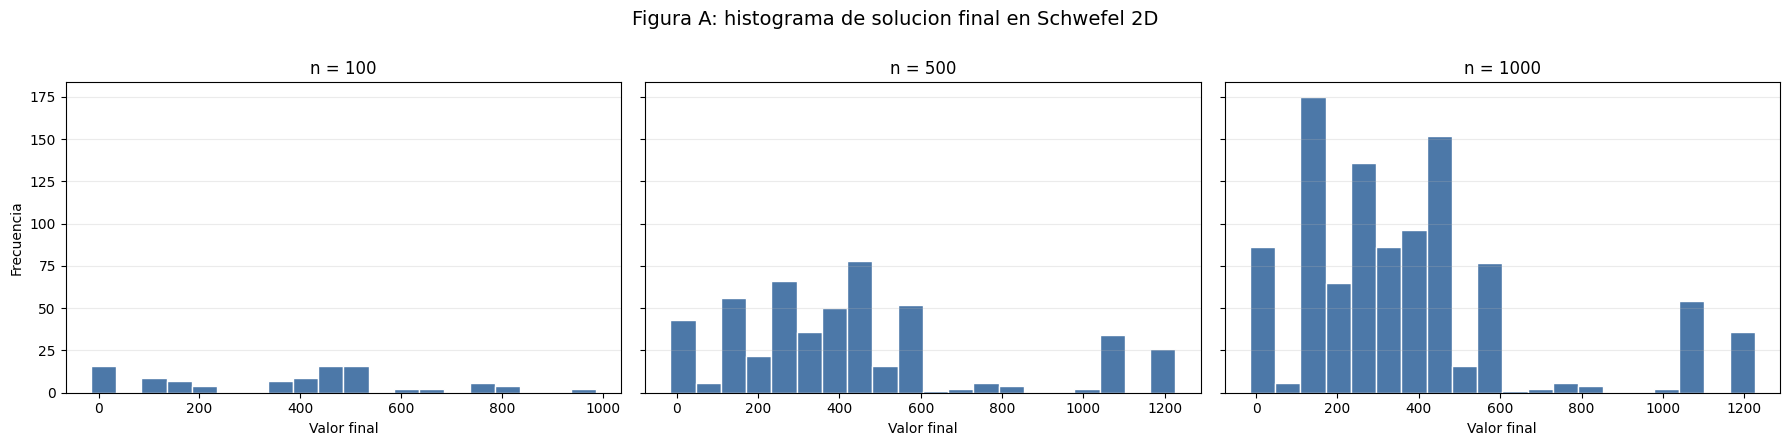

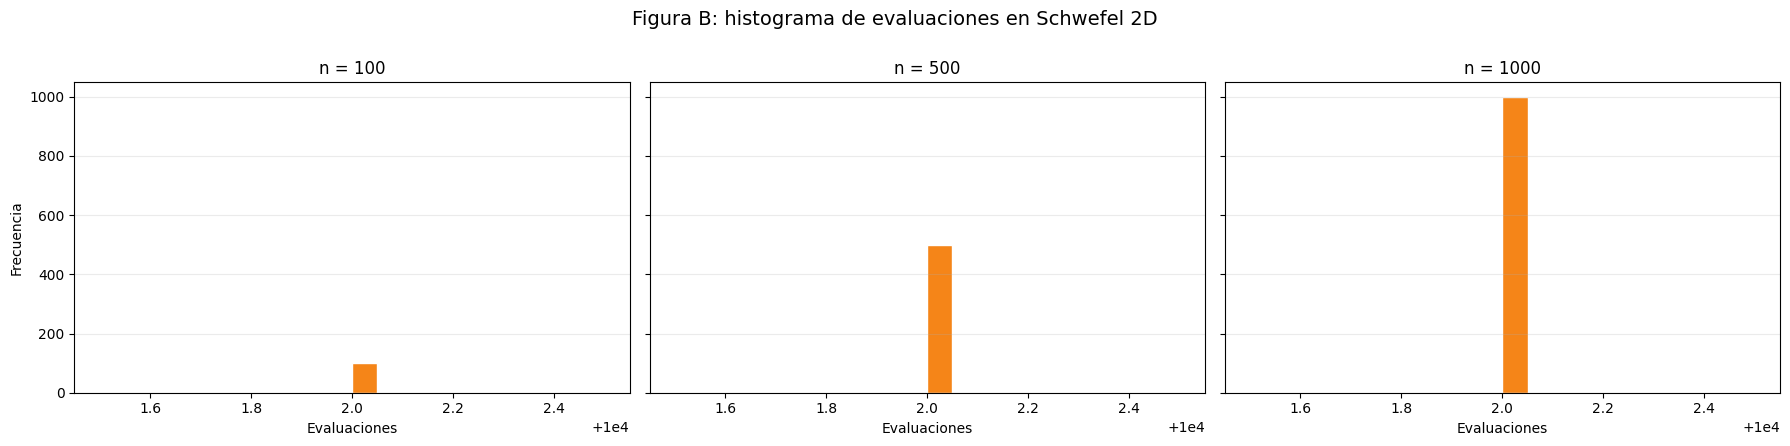

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/schwefel_figura_b_histograma_evaluaciones_2d.png')

In [89]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

schwefel_runs_2d = prepare_function_runs(runs_df, run_files, "schwefel", 2)
sample_sizes = [100, 500, 1000]
schwefel_figures_dir = DATA_DIR / "figuras"
schwefel_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_schwefel_2d = plot_final_value_histogram(
    schwefel_runs_2d,
    function_label="Schwefel",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_schwefel_2d_path = schwefel_figures_dir / "schwefel_figura_a_histograma_solucion_final_2d.png"
fig_a_schwefel_2d_path = save_figure(fig_a_schwefel_2d, fig_a_schwefel_2d_path)
plt.show()
fig_a_schwefel_2d_path

fig_b_schwefel_2d = plot_evaluations_histogram(
    schwefel_runs_2d,
    function_label="Schwefel",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_schwefel_2d_path = schwefel_figures_dir / "schwefel_figura_b_histograma_evaluaciones_2d.png"
fig_b_schwefel_2d_path = save_figure(fig_b_schwefel_2d, fig_b_schwefel_2d_path)
plt.show()
fig_b_schwefel_2d_path


##### Histogramas por tamano de muestra para Schwefel 3D

Se replica el mismo formato para `Schwefel 3D`, de modo que la comparacion con `2D` y entre tamanos de muestra sea directa.


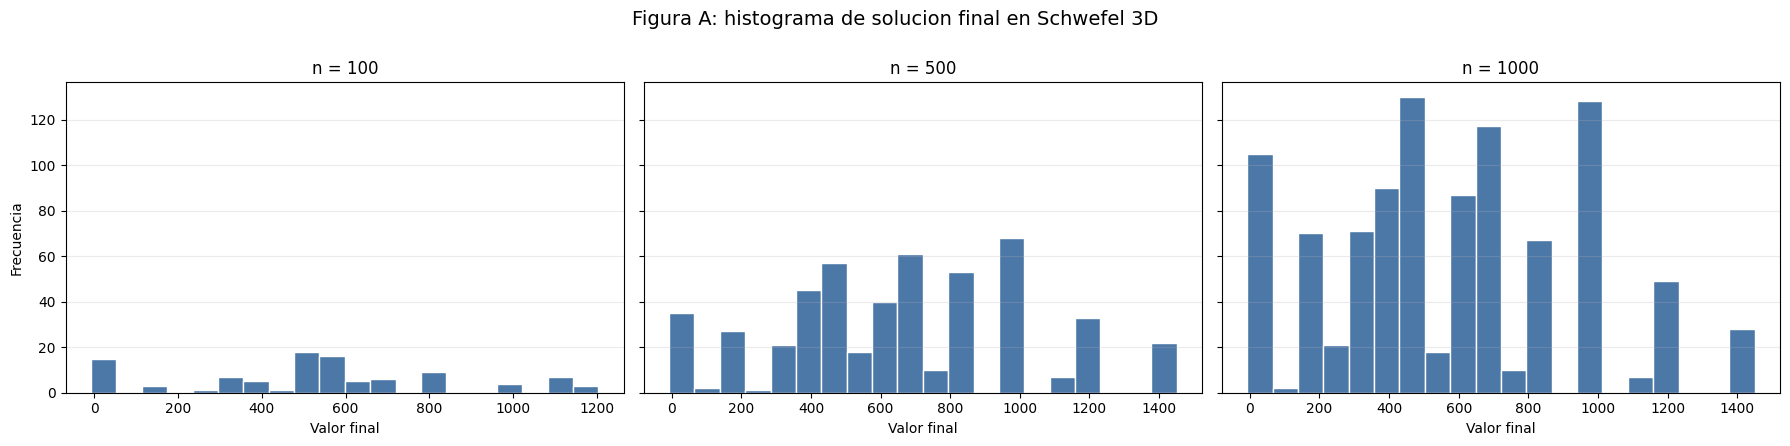

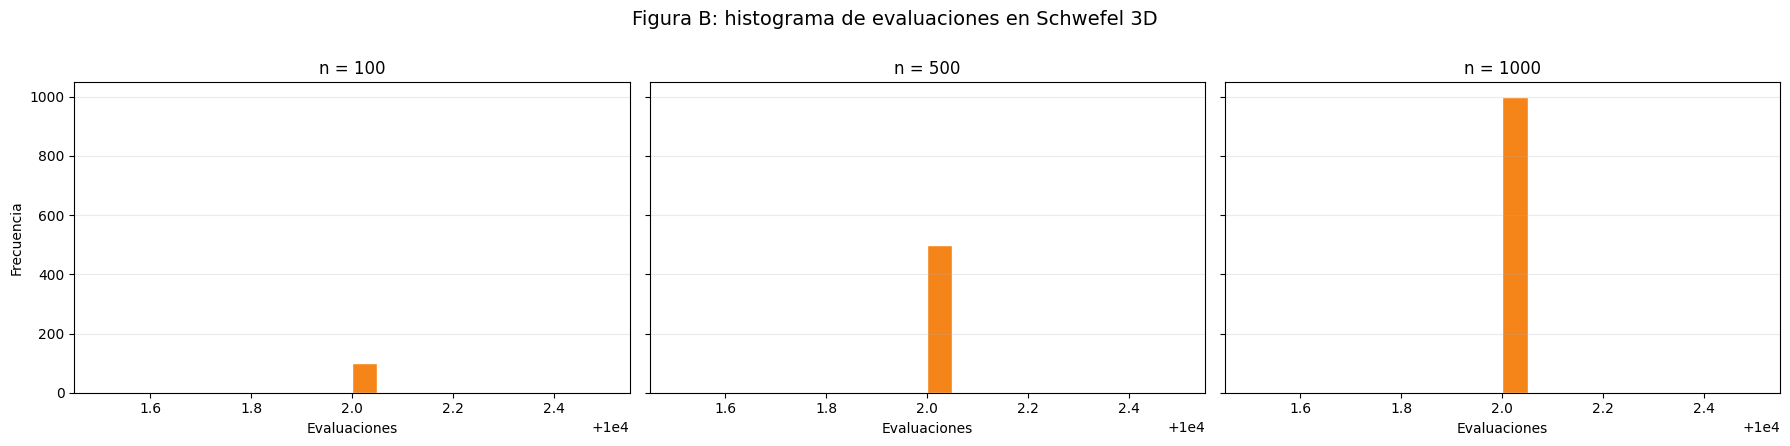

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/schwefel_figura_b_histograma_evaluaciones_3d.png')

In [90]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

schwefel_runs_3d = prepare_function_runs(runs_df, run_files, "schwefel", 3)
sample_sizes = [100, 500, 1000]
schwefel_figures_dir = DATA_DIR / "figuras"
schwefel_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_schwefel_3d = plot_final_value_histogram(
    schwefel_runs_3d,
    function_label="Schwefel",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_a_schwefel_3d_path = schwefel_figures_dir / "schwefel_figura_a_histograma_solucion_final_3d.png"
fig_a_schwefel_3d_path = save_figure(fig_a_schwefel_3d, fig_a_schwefel_3d_path)
plt.show()
fig_a_schwefel_3d_path

fig_b_schwefel_3d = plot_evaluations_histogram(
    schwefel_runs_3d,
    function_label="Schwefel",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_b_schwefel_3d_path = schwefel_figures_dir / "schwefel_figura_b_histograma_evaluaciones_3d.png"
fig_b_schwefel_3d_path = save_figure(fig_b_schwefel_3d, fig_b_schwefel_3d_path)
plt.show()
fig_b_schwefel_3d_path


##### Tabla resumen de Schwefel 2D

La tabla siguiente resume `Mejor valor`, `Peor valor`, `Promedio`, `Desviacion estandar` y `Promedio de evaluaciones` para `Schwefel 2D`.


In [91]:
from report_utils import build_summary_table
tabla_resumen_schwefel_2d = build_summary_table(
    summary_df,
    "schwefel",
    2,
    dimension_label="2D",
    function_label="Schwefel",
)
tabla_resumen_schwefel_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Schwefel,2D,100,-15.320704,985.872489,369.838489,254.486316,10002.0
1,Schwefel,2D,500,-15.320704,1225.634336,430.805149,317.567768,10002.0
2,Schwefel,2D,1000,-15.320704,1225.634336,376.585731,291.548457,10002.0


##### Tabla resumen de Schwefel 3D

Se mantiene la misma tabla resumen para `Schwefel 3D`, facilitando una comparacion directa con el caso bidimensional.


In [92]:
from report_utils import build_summary_table
tabla_resumen_schwefel_3d = build_summary_table(
    summary_df,
    "schwefel",
    3,
    dimension_label="3D",
    function_label="Schwefel",
)
tabla_resumen_schwefel_3d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Schwefel,3D,100,-7.734811,1203.495313,538.472189,325.662981,10002.0
1,Schwefel,3D,500,-7.734811,1450.156384,650.606775,354.563288,10002.0
2,Schwefel,3D,1000,-7.734811,1450.156384,565.924273,351.705855,10002.0


##### Interpretacion de resultados para Schwefel

En `Schwefel`, el descenso por gradiente muestra una **convergencia util pero poco robusta**. El algoritmo logra alcanzar soluciones relativamente buenas en el mejor caso, con valores negativos tanto en `2D` (`-15.320704`) como en `3D` (`-7.734811`), lo que indica que si puede acercarse a regiones favorables de la funcion. Sin embargo, esa convergencia no es consistente entre corridas, porque los peores valores siguen siendo muy altos y los promedios permanecen lejos del mejor resultado observado.

La dispersion de los resultados es alta en ambas dimensiones. En `2D`, los promedios oscilan entre `369.84` y `430.81`, con desviaciones estandar entre `254.49` y `317.57`. En `3D`, la situacion es aun mas exigente: los promedios suben a un rango aproximado entre `538.47` y `650.61`, y la desviacion estandar se mantiene elevada, entre `325.66` y `354.56`. Esto sugiere una sensibilidad importante al punto inicial y una mayor dificultad del metodo para estabilizarse cuando la funcion se evalua en tres dimensiones.

Desde el punto de vista del costo computacional, el comportamiento es **alto y completamente estable**, ya que el promedio de evaluaciones es `10002.0` en todos los escenarios. Eso indica que, en la practica, casi todas las corridas llegan al limite de iteraciones configurado, en lugar de detenerse antes por una convergencia clara. Al aumentar el numero de corridas de `100` a `500` y `1000`, no disminuye el costo por corrida, pero si se obtiene una estimacion mas estable del comportamiento global. En conjunto, `Schwefel 2D` presenta mejores promedios y menor dispersion que `Schwefel 3D`, por lo que el paso a `3D` empeora la calidad promedio de las soluciones y refuerza la idea de que esta funcion resulta mas dificil para el descenso por gradiente.


### 3.3 Rastrigin

La funcion de Rastrigin permite observar el efecto de una superficie multimodal sobre el descenso por gradiente, especialmente por la presencia de muchos minimos locales.

Aqui se resume su comportamiento en `2D` y `3D` para  = 100`, `500` y `1000`, usando el mismo esquema de figuras y tablas del resto del analisis.


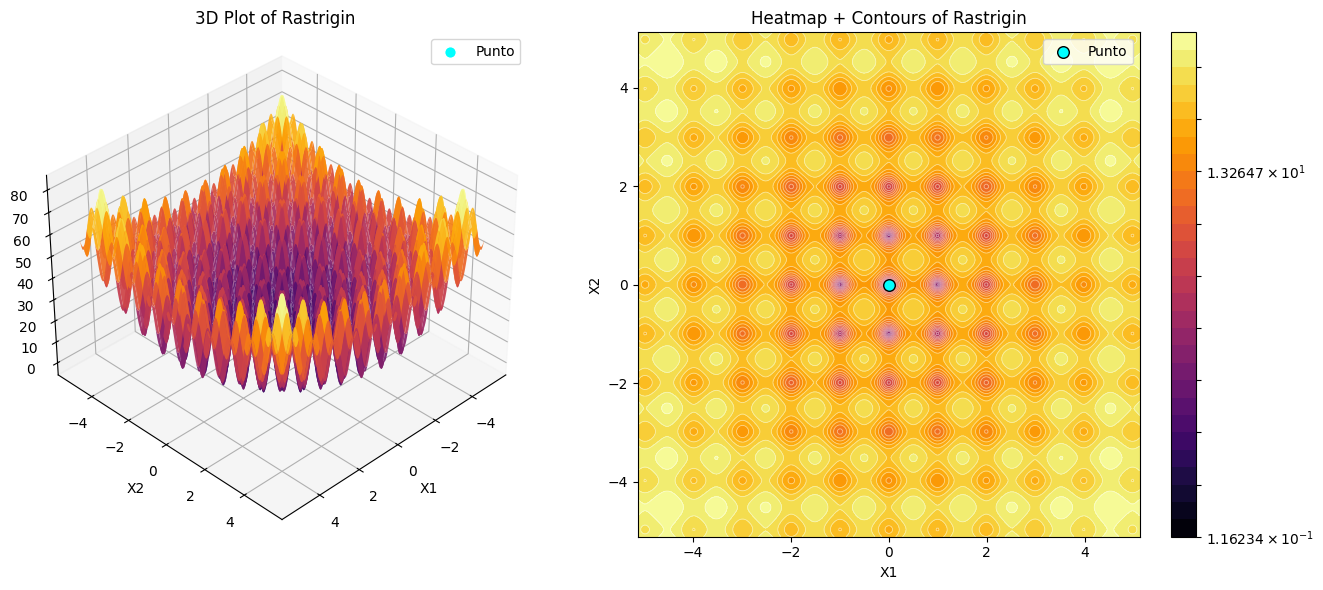

In [93]:
cfg = FUNCTION_VISUAL_CONFIGS["rastrigin"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
        output_path=FIGURES_DIR / "rastrigin_mapa_calor_y_superficie.png",
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


#### Resultados de Rastrigin

A continuacion se organiza el analisis experimental de Rastrigin con el mismo esquema usado en Rosenbrock, separando calidad de solucion, costo computacional y tablas resumen.

- histogramas de `valor_final` para medir cercania al optimo
- histogramas de `evaluaciones` para medir costo computacional
- tablas resumen para comparar comportamiento entre tamanos de muestra


##### Histogramas por tamano de muestra para Rastrigin 2D

Para `Rastrigin 2D` se muestran histogramas de `valor_final` y `evaluaciones` para  = 100`, `500` y `1000`, manteniendo el mismo criterio visual del resto del reporte.


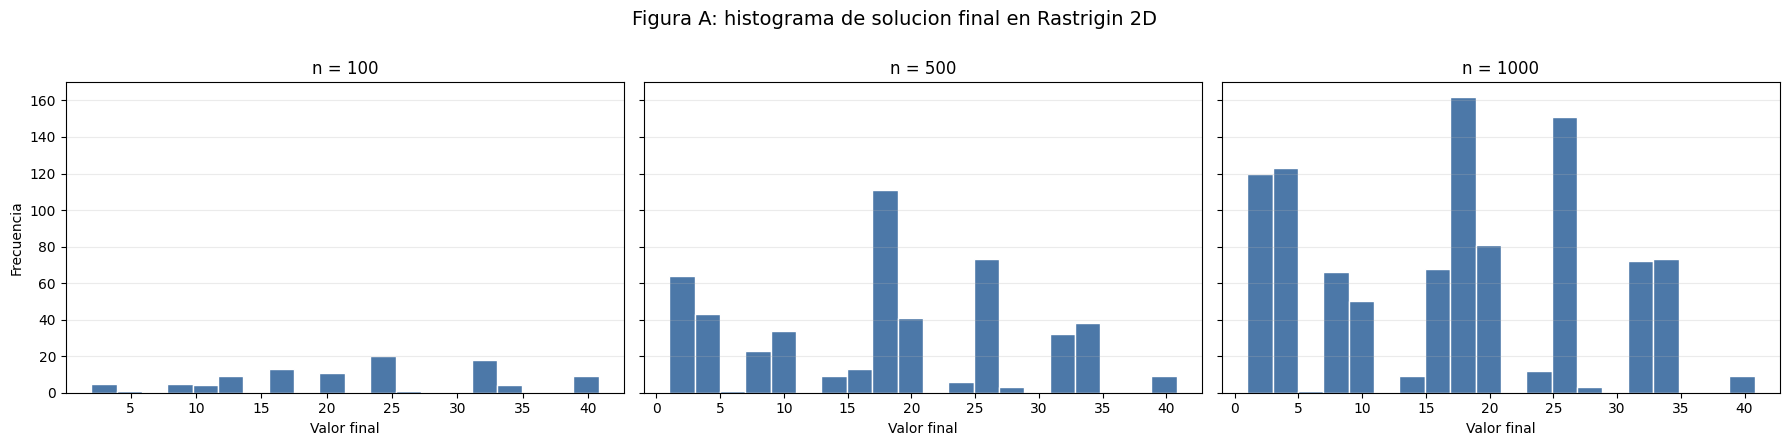

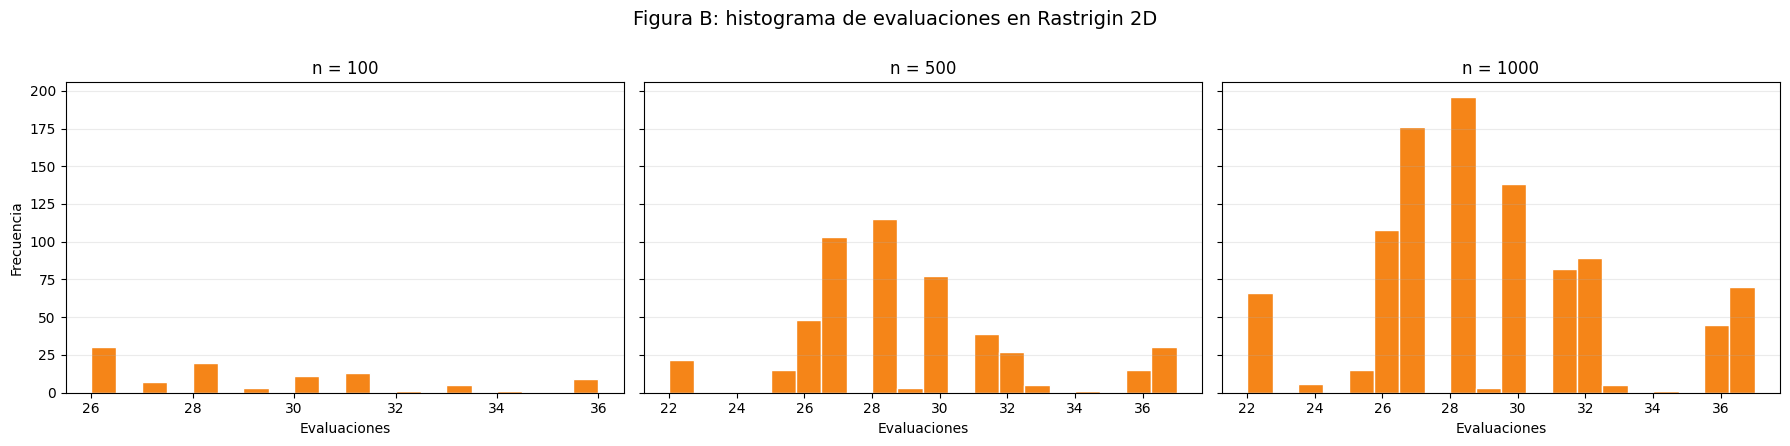

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/rastrigin_figura_b_histograma_evaluaciones_2d.png')

In [94]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

rastrigin_runs_2d = prepare_function_runs(runs_df, run_files, "rastrigin", 2)
sample_sizes = [100, 500, 1000]
rastrigin_figures_dir = DATA_DIR / "figuras"
rastrigin_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_rastrigin_2d = plot_final_value_histogram(
    rastrigin_runs_2d,
    function_label="Rastrigin",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_rastrigin_2d_path = rastrigin_figures_dir / "rastrigin_figura_a_histograma_solucion_final_2d.png"
fig_a_rastrigin_2d_path = save_figure(fig_a_rastrigin_2d, fig_a_rastrigin_2d_path)
plt.show()
fig_a_rastrigin_2d_path

fig_b_rastrigin_2d = plot_evaluations_histogram(
    rastrigin_runs_2d,
    function_label="Rastrigin",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_rastrigin_2d_path = rastrigin_figures_dir / "rastrigin_figura_b_histograma_evaluaciones_2d.png"
fig_b_rastrigin_2d_path = save_figure(fig_b_rastrigin_2d, fig_b_rastrigin_2d_path)
plt.show()
fig_b_rastrigin_2d_path


##### Histogramas por tamano de muestra para Rastrigin 3D

Se replica el mismo formato para `Rastrigin 3D`, de modo que la comparacion con `2D` y entre tamanos de muestra sea directa.


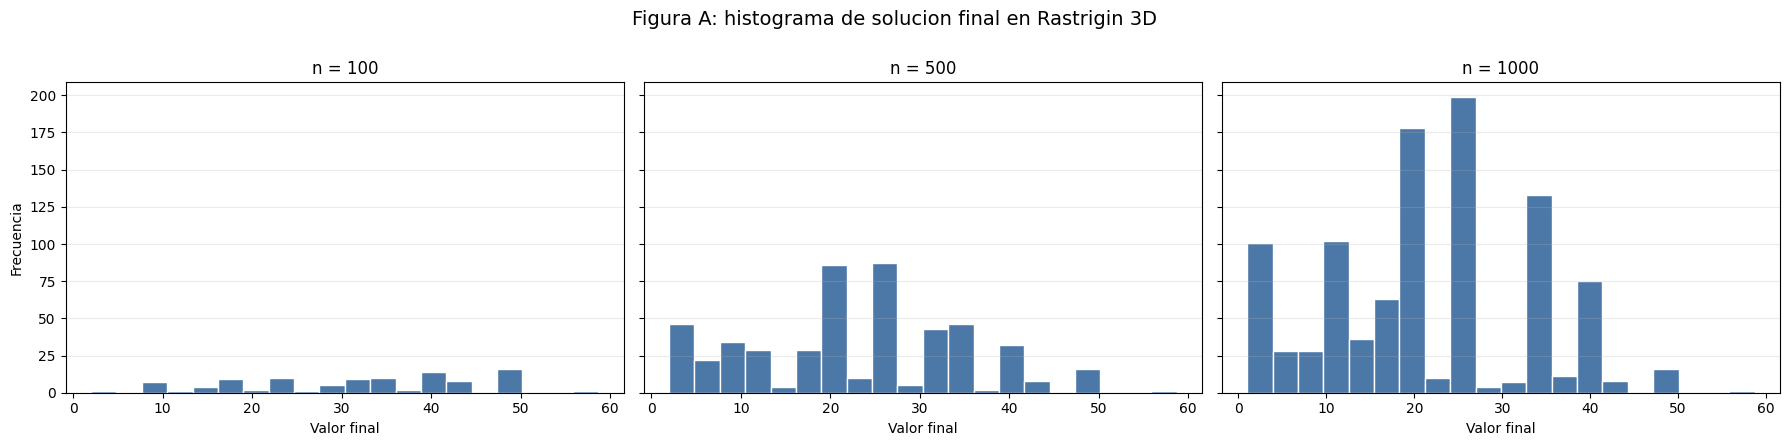

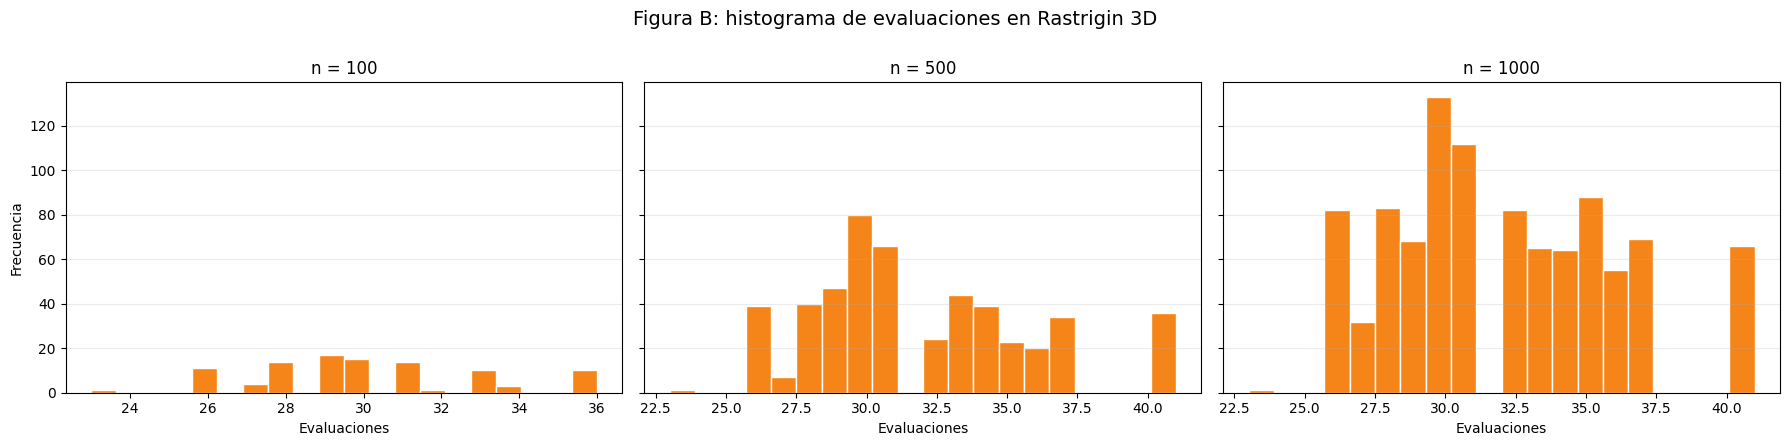

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/rastrigin_figura_b_histograma_evaluaciones_3d.png')

In [95]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

rastrigin_runs_3d = prepare_function_runs(runs_df, run_files, "rastrigin", 3)
sample_sizes = [100, 500, 1000]
rastrigin_figures_dir = DATA_DIR / "figuras"
rastrigin_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_rastrigin_3d = plot_final_value_histogram(
    rastrigin_runs_3d,
    function_label="Rastrigin",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_a_rastrigin_3d_path = rastrigin_figures_dir / "rastrigin_figura_a_histograma_solucion_final_3d.png"
fig_a_rastrigin_3d_path = save_figure(fig_a_rastrigin_3d, fig_a_rastrigin_3d_path)
plt.show()
fig_a_rastrigin_3d_path

fig_b_rastrigin_3d = plot_evaluations_histogram(
    rastrigin_runs_3d,
    function_label="Rastrigin",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_b_rastrigin_3d_path = rastrigin_figures_dir / "rastrigin_figura_b_histograma_evaluaciones_3d.png"
fig_b_rastrigin_3d_path = save_figure(fig_b_rastrigin_3d, fig_b_rastrigin_3d_path)
plt.show()
fig_b_rastrigin_3d_path


##### Tabla resumen de Rastrigin 2D

La tabla siguiente resume `Mejor valor`, `Peor valor`, `Promedio`, `Desviacion estandar` y `Promedio de evaluaciones` para `Rastrigin 2D`.


In [96]:
from report_utils import build_summary_table
tabla_resumen_rastrigin_2d = build_summary_table(
    summary_df,
    "rastrigin",
    2,
    dimension_label="2D",
    function_label="Rastrigin",
)
tabla_resumen_rastrigin_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Rastrigin,2D,100,1.989918,40.792967,22.446131,10.328634,29.040
1,Rastrigin,2D,500,0.994959,40.792967,17.043546,10.538270,28.854
2,Rastrigin,2D,1000,0.994959,40.792967,16.481399,10.576092,29.045


##### Tabla resumen de Rastrigin 3D

Se mantiene la misma tabla resumen para `Rastrigin 3D`, facilitando una comparacion directa con el caso bidimensional.


In [97]:
from report_utils import build_summary_table
tabla_resumen_rastrigin_3d = build_summary_table(
    summary_df,
    "rastrigin",
    3,
    dimension_label="3D",
    function_label="Rastrigin",
)
tabla_resumen_rastrigin_3d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Rastrigin,3D,100,1.989918,58.702047,31.947931,13.037185,30.100
1,Rastrigin,3D,500,1.989918,58.702047,22.706825,12.308730,31.920
2,Rastrigin,3D,1000,0.994959,58.702047,21.551687,11.735034,32.041


##### Interpretacion de resultados para Rastrigin

En `Rastrigin`, el descenso por gradiente muestra una **convergencia parcial y dependiente del punto inicial**. El algoritmo logra encontrar soluciones relativamente cercanas al optimo en el mejor caso, con valores de `0.994959` en `2D` y `3D`, e incluso un valor de `1.989918` en los escenarios menos favorables. Esto indica que el metodo puede acercarse a minimos bajos de la funcion, pero no de manera sistematica al optimo global, algo esperable en una superficie multimodal como Rastrigin.

La dispersion de resultados es moderada y persistente en ambas dimensiones. En `2D`, los promedios bajan de `22.45` a `16.48` cuando se pasa de `100` a `1000` corridas, con desviaciones estandar cercanas a `10.3` y `10.6`. En `3D`, los promedios son peores, entre `31.95` y `21.55`, y las desviaciones estandar tambien son mayores, entre `11.74` y `13.04`. En conjunto, esto sugiere que el algoritmo mantiene una variabilidad importante entre corridas y que el aumento de dimension hace mas dificil encontrar regiones tan favorables como en el caso bidimensional.

En cuanto al costo computacional, el comportamiento es **bajo y muy estable** comparado con funciones como Schwefel o Rosenbrock. El promedio de evaluaciones se mantiene alrededor de `29` en `2D` y de `30` a `32` en `3D`, lo que sugiere una convergencia o detencion temprana mucho mas rapida. Al aumentar el numero de corridas, se observa una mejora en los promedios, especialmente en `2D`, y una ligera reduccion de la dispersion en `3D`. En conjunto, `Rastrigin 2D` presenta mejores soluciones promedio y menor costo que `Rastrigin 3D`, mientras que `3D` conserva el mismo mejor caso final, pero con peores promedios y una variabilidad algo mayor.


### 3.4 Griewank

La funcion de Griewank se analiza como otra superficie multimodal, util para comparar que tanto cambia la estabilidad del metodo cuando el paisaje presenta oscilaciones y multiples zonas de atraccion.

En esta seccion se revisan los resultados en `2D` y `3D`, siempre con  = 100`, `500` y `1000` corridas independientes.


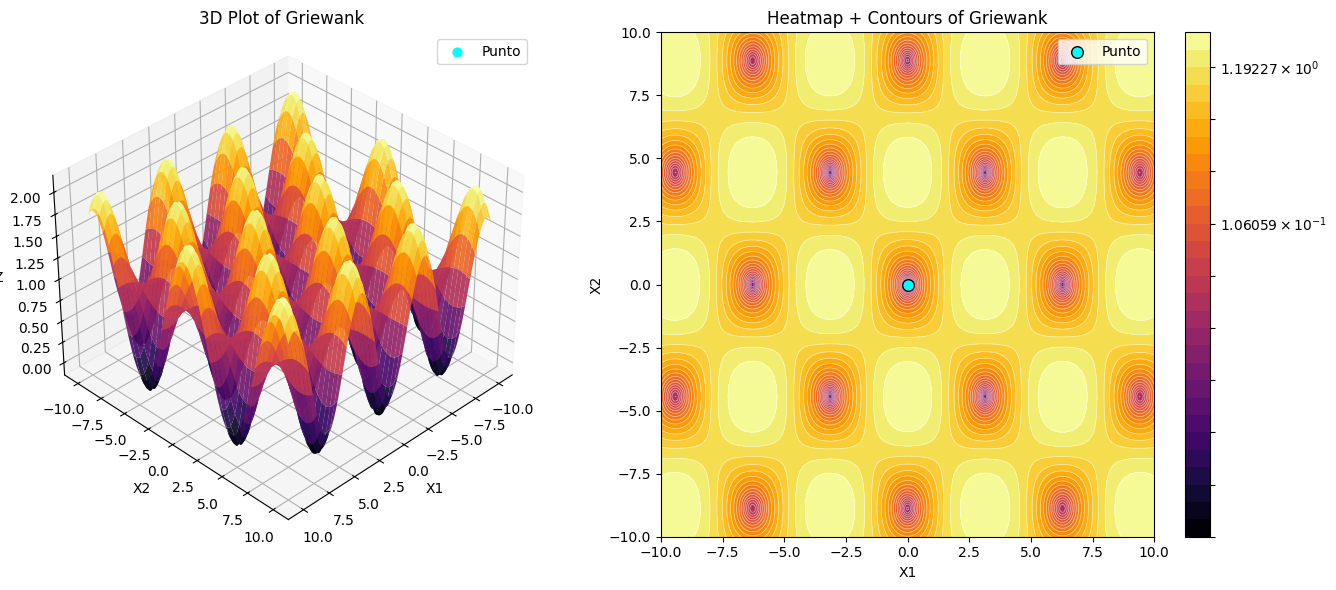

In [98]:
cfg = FUNCTION_VISUAL_CONFIGS["griewank"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
        output_path=FIGURES_DIR / "griewank_mapa_calor_y_superficie.png",
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


#### Resultados de Griewank

A continuacion se organiza el analisis experimental de Griewank con el mismo esquema usado en Rosenbrock, separando calidad de solucion, costo computacional y tablas resumen.

- histogramas de `valor_final` para medir cercania al optimo
- histogramas de `evaluaciones` para medir costo computacional
- tablas resumen para comparar comportamiento entre tamanos de muestra


##### Histogramas por tamano de muestra para Griewank 2D

Para `Griewank 2D` se muestran histogramas de `valor_final` y `evaluaciones` para  = 100`, `500` y `1000`, manteniendo el mismo criterio visual del resto del reporte.


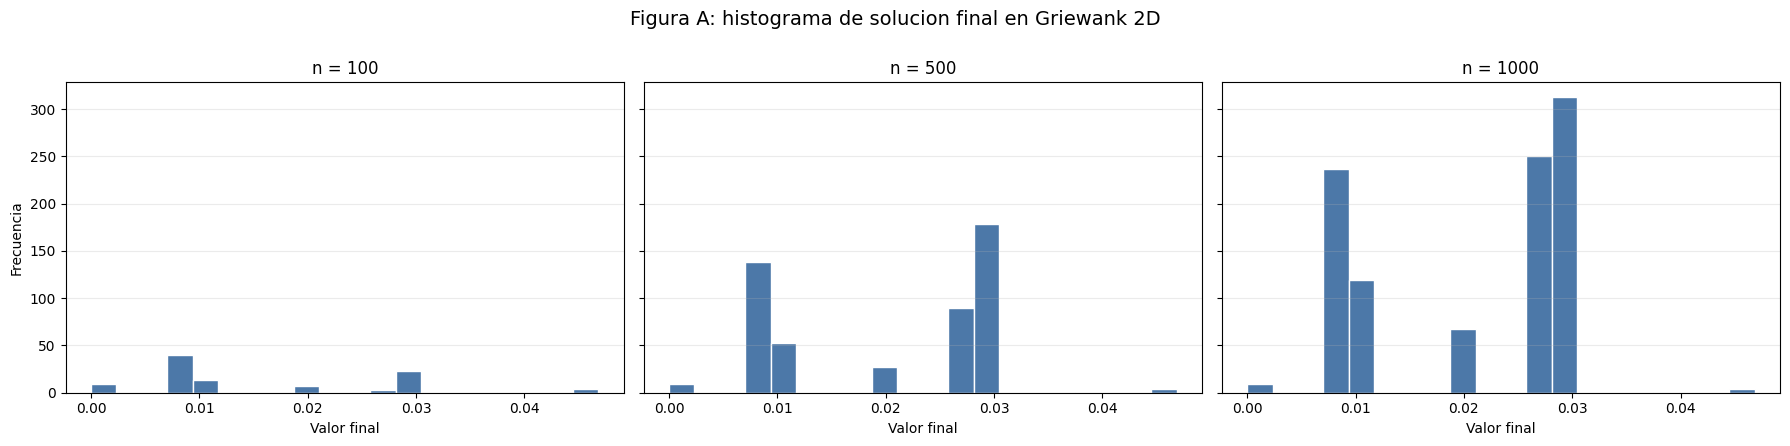

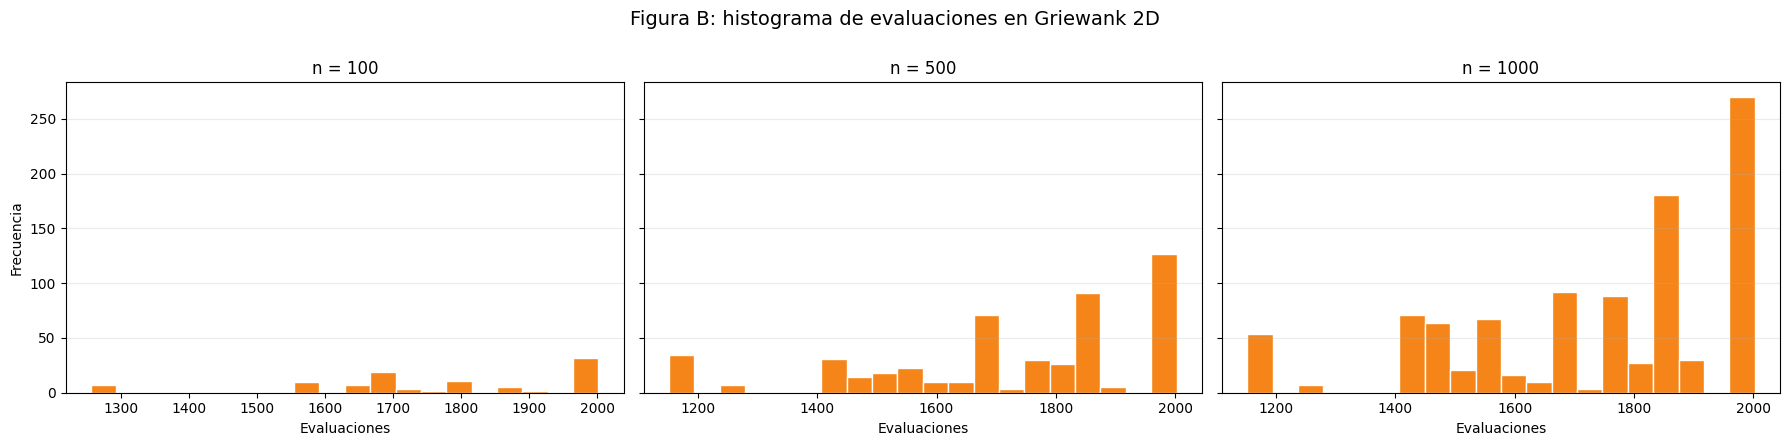

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/griewank_figura_b_histograma_evaluaciones_2d.png')

In [99]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

griewank_runs_2d = prepare_function_runs(runs_df, run_files, "griewank", 2)
sample_sizes = [100, 500, 1000]
griewank_figures_dir = DATA_DIR / "figuras"
griewank_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_griewank_2d = plot_final_value_histogram(
    griewank_runs_2d,
    function_label="Griewank",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_griewank_2d_path = griewank_figures_dir / "griewank_figura_a_histograma_solucion_final_2d.png"
fig_a_griewank_2d_path = save_figure(fig_a_griewank_2d, fig_a_griewank_2d_path)
plt.show()
fig_a_griewank_2d_path

fig_b_griewank_2d = plot_evaluations_histogram(
    griewank_runs_2d,
    function_label="Griewank",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_griewank_2d_path = griewank_figures_dir / "griewank_figura_b_histograma_evaluaciones_2d.png"
fig_b_griewank_2d_path = save_figure(fig_b_griewank_2d, fig_b_griewank_2d_path)
plt.show()
fig_b_griewank_2d_path


##### Histogramas por tamano de muestra para Griewank 3D

Se replica el mismo formato para `Griewank 3D`, de modo que la comparacion con `2D` y entre tamanos de muestra sea directa.


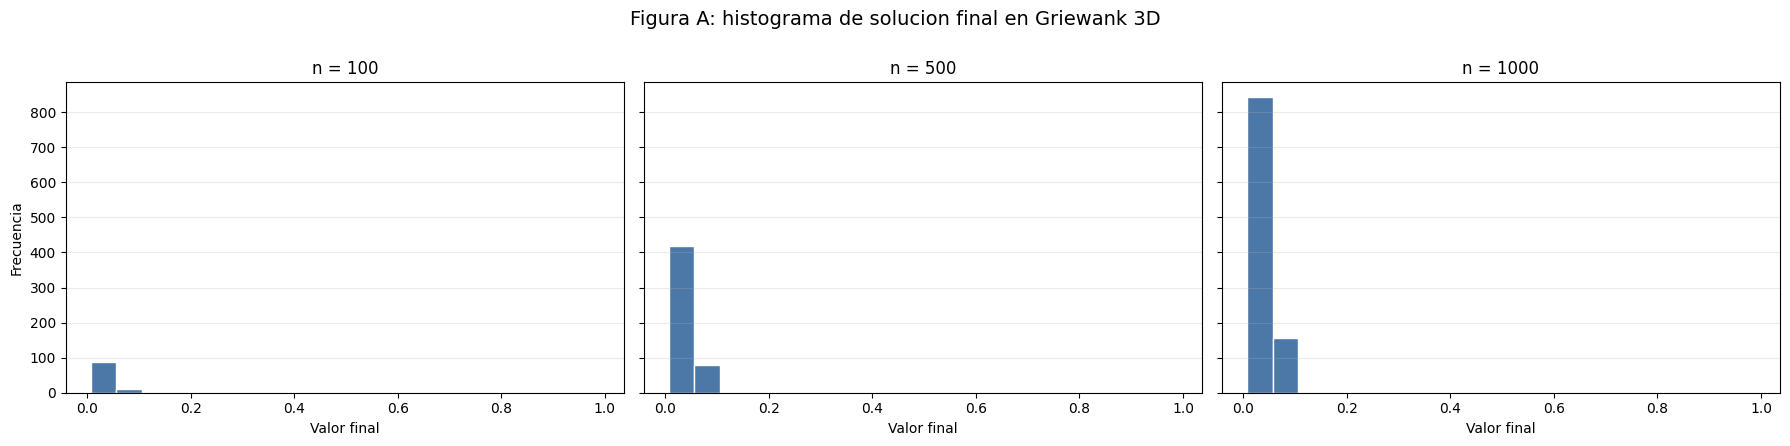

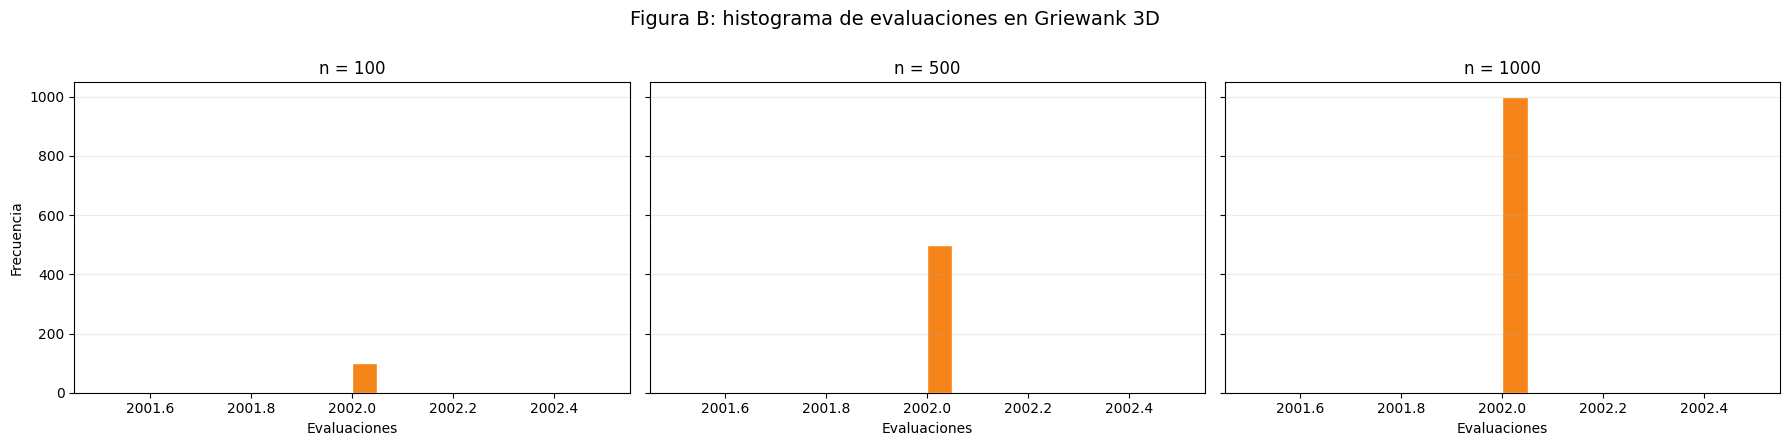

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/griewank_figura_b_histograma_evaluaciones_3d.png')

In [100]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

griewank_runs_3d = prepare_function_runs(runs_df, run_files, "griewank", 3)
sample_sizes = [100, 500, 1000]
griewank_figures_dir = DATA_DIR / "figuras"
griewank_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_griewank_3d = plot_final_value_histogram(
    griewank_runs_3d,
    function_label="Griewank",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_a_griewank_3d_path = griewank_figures_dir / "griewank_figura_a_histograma_solucion_final_3d.png"
fig_a_griewank_3d_path = save_figure(fig_a_griewank_3d, fig_a_griewank_3d_path)
plt.show()
fig_a_griewank_3d_path

fig_b_griewank_3d = plot_evaluations_histogram(
    griewank_runs_3d,
    function_label="Griewank",
    dimension_label="3D",
    sample_sizes=sample_sizes,
)
fig_b_griewank_3d_path = griewank_figures_dir / "griewank_figura_b_histograma_evaluaciones_3d.png"
fig_b_griewank_3d_path = save_figure(fig_b_griewank_3d, fig_b_griewank_3d_path)
plt.show()
fig_b_griewank_3d_path


##### Tabla resumen de Griewank 2D

La tabla siguiente resume `Mejor valor`, `Peor valor`, `Promedio`, `Desviacion estandar` y `Promedio de evaluaciones` para `Griewank 2D`.


In [101]:
from report_utils import build_summary_table
tabla_resumen_griewank_2d = build_summary_table(
    summary_df,
    "griewank",
    2,
    dimension_label="2D",
    function_label="Griewank",
)
tabla_resumen_griewank_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Griewank,2D,100,0.0,0.046835,0.015507,0.012164,1766.940
1,Griewank,2D,500,0.0,0.046835,0.020020,0.010502,1732.034
2,Griewank,2D,1000,0.0,0.046835,0.020516,0.009895,1741.053


##### Tabla resumen de Griewank 3D

Se mantiene la misma tabla resumen para `Griewank 3D`, facilitando una comparacion directa con el caso bidimensional.


In [102]:
from report_utils import build_summary_table
tabla_resumen_griewank_3d = build_summary_table(
    summary_df,
    "griewank",
    3,
    dimension_label="3D",
    function_label="Griewank",
)
tabla_resumen_griewank_3d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Griewank,3D,100,0.007399,0.987636,0.037499,0.096662,2002.0
1,Griewank,3D,500,0.007399,0.987636,0.035174,0.044538,2002.0
2,Griewank,3D,1000,0.007399,0.987636,0.034752,0.032460,2002.0


##### Interpretacion de resultados para Griewank

En `Griewank`, el descenso por gradiente muestra una **convergencia claramente mas adecuada** que en funciones como Schwefel o Rastrigin. En `2D`, el mejor valor alcanza exactamente `0.0`, y en `3D` llega a `0.007399`, lo que indica que el algoritmo encuentra soluciones muy cercanas al optimo global en ambos casos. Ademas, los promedios se mantienen muy bajos, especialmente en `2D`, donde oscilan entre `0.0155` y `0.0205`, mientras que en `3D` permanecen entre `0.0348` y `0.0375`.

La dispersion general es baja, aunque con una diferencia importante entre dimensiones. En `2D`, la desviacion estandar se mantiene alrededor de `0.01`, lo que sugiere resultados bastante consistentes entre corridas. En `3D`, la dispersion es mayor para `n = 100` (`0.0967`), pero disminuye con claridad al pasar a `500` y `1000` corridas, donde baja a `0.0445` y `0.0325`. Esto muestra que el metodo sigue siendo estable, pero que la dimension adicional introduce una variabilidad inicial mas alta que luego se compensa al aumentar el tamano de muestra.

En cuanto al costo computacional, el comportamiento es **intermedio y muy estable**. En `2D`, el promedio de evaluaciones se mueve cerca de `1732` a `1767`, mientras que en `3D` queda fijo en `2002.0`, lo que sugiere nuevamente una fuerte influencia del criterio de parada configurado. Al aumentar el numero de corridas, el promedio en `3D` mejora levemente y la dispersion disminuye, mientras que en `2D` los resultados ya eran muy buenos desde el inicio y cambian poco. En conjunto, `Griewank 2D` ofrece mejores valores promedio y menor dispersion que `Griewank 3D`, aunque en ambas dimensiones el metodo logra converger a soluciones cercanas al optimo con bastante regularidad.


### 3.5 Goldstein-Price

Goldstein-Price se presenta en su formulacion bidimensional clasica, por lo que el analisis se concentra en `2D` y en la distribucion de resultados obtenidos por el descenso por gradiente.

Se conserva el mismo formato de histogramas y tabla resumen para mantener consistencia con las otras funciones del reporte.


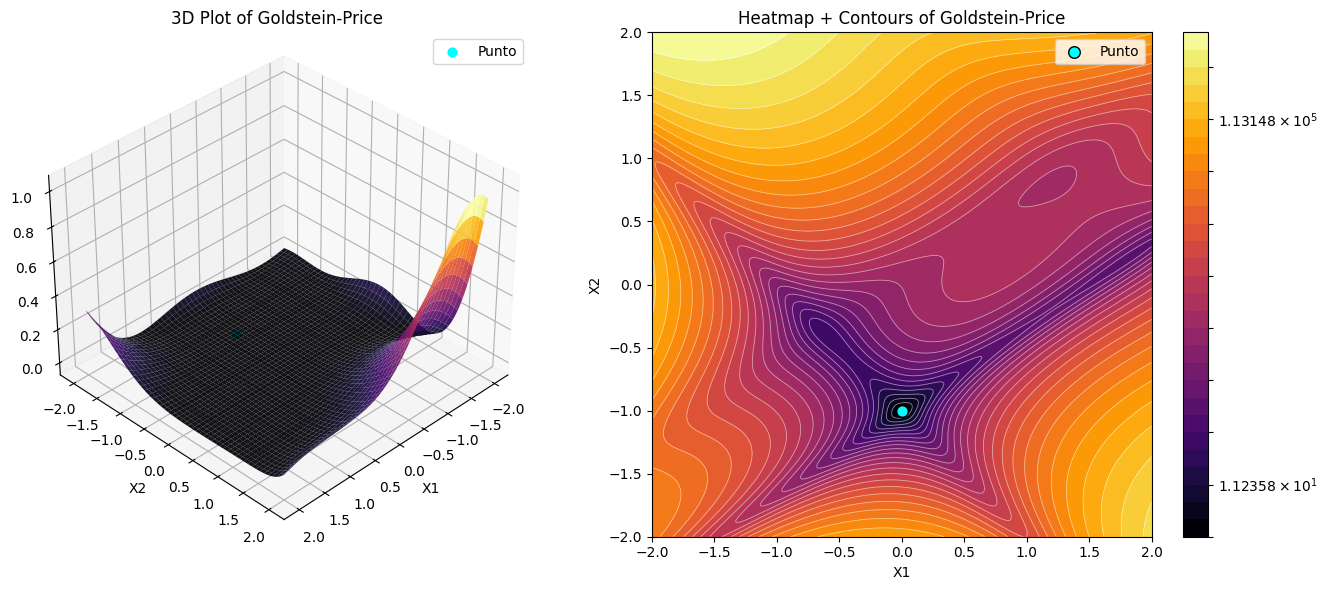

In [103]:
cfg = FUNCTION_VISUAL_CONFIGS["goldstein_price"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
        output_path=FIGURES_DIR / "goldstein_price_mapa_calor_y_superficie.png",
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


#### Resultados de Goldstein-Price

A continuacion se organiza el analisis experimental de Goldstein-Price con el mismo esquema usado en Rosenbrock, separando calidad de solucion, costo computacional y tablas resumen.

- histogramas de `valor_final` para medir cercania al optimo
- histogramas de `evaluaciones` para medir costo computacional
- tablas resumen para comparar comportamiento entre tamanos de muestra


##### Histogramas por tamano de muestra para Goldstein-Price 2D

Para `Goldstein-Price 2D` se muestran histogramas de `valor_final` y `evaluaciones` para  = 100`, `500` y `1000`, manteniendo el mismo criterio visual del resto del reporte.


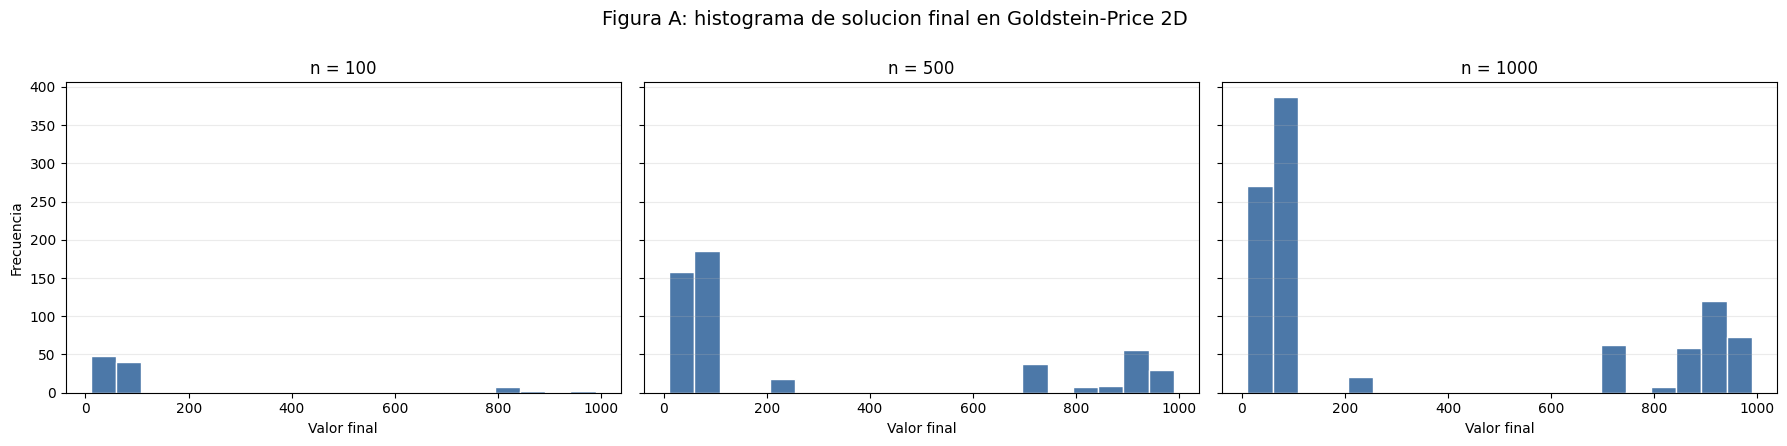

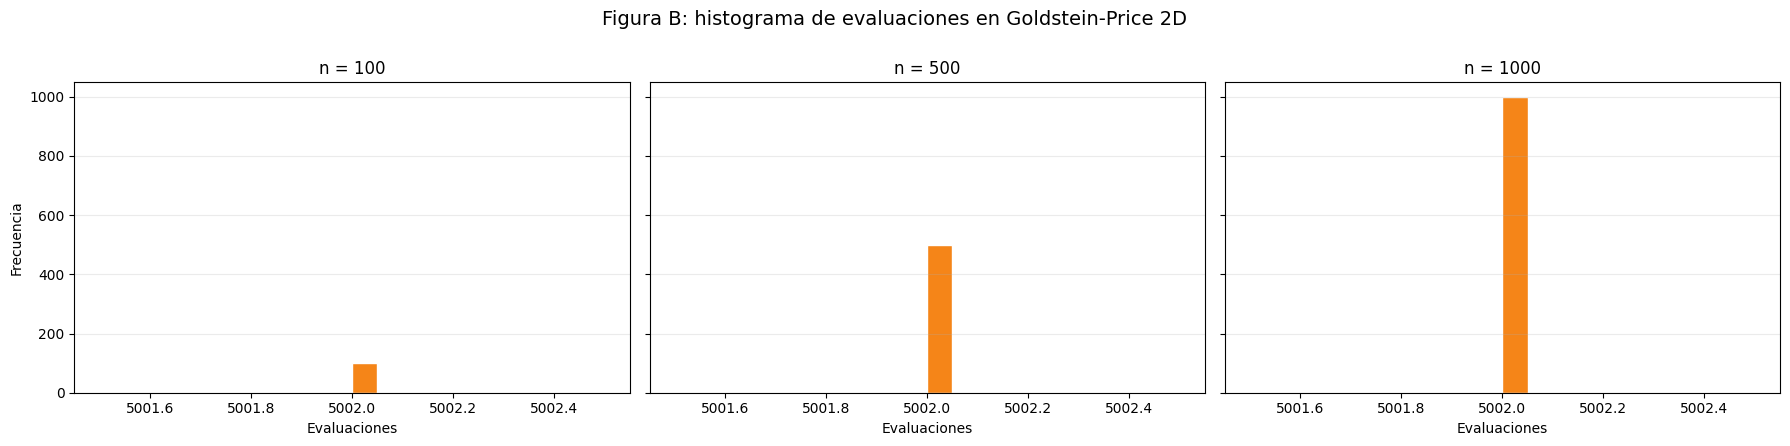

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/goldstein_price_figura_b_histograma_evaluaciones_2d.png')

In [104]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

goldstein_price_runs_2d = prepare_function_runs(runs_df, run_files, "goldstein_price", 2)
sample_sizes = [100, 500, 1000]
goldstein_price_figures_dir = DATA_DIR / "figuras"
goldstein_price_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_goldstein_price_2d = plot_final_value_histogram(
    goldstein_price_runs_2d,
    function_label="Goldstein-Price",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_goldstein_price_2d_path = goldstein_price_figures_dir / "goldstein_price_figura_a_histograma_solucion_final_2d.png"
fig_a_goldstein_price_2d_path = save_figure(fig_a_goldstein_price_2d, fig_a_goldstein_price_2d_path)
plt.show()
fig_a_goldstein_price_2d_path

fig_b_goldstein_price_2d = plot_evaluations_histogram(
    goldstein_price_runs_2d,
    function_label="Goldstein-Price",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_goldstein_price_2d_path = goldstein_price_figures_dir / "goldstein_price_figura_b_histograma_evaluaciones_2d.png"
fig_b_goldstein_price_2d_path = save_figure(fig_b_goldstein_price_2d, fig_b_goldstein_price_2d_path)
plt.show()
fig_b_goldstein_price_2d_path


##### Tabla resumen de Goldstein-Price 2D

La tabla siguiente resume `Mejor valor`, `Peor valor`, `Promedio`, `Desviacion estandar` y `Promedio de evaluaciones` para `Goldstein-Price 2D`.


In [105]:
from report_utils import build_summary_table
tabla_resumen_goldstein_price_2d = build_summary_table(
    summary_df,
    "goldstein_price",
    2,
    dimension_label="2D",
    function_label="Goldstein-Price",
)
tabla_resumen_goldstein_price_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Goldstein-Price,2D,100,10.492143,988.649509,148.951757,264.292727,5002.0
1,Goldstein-Price,2D,500,10.492143,989.718375,288.418848,361.561268,5002.0
2,Goldstein-Price,2D,1000,10.492143,989.718375,328.077633,382.519685,5002.0


##### Interpretacion de resultados para Goldstein-Price

En `Goldstein-Price 2D`, el descenso por gradiente muestra una **convergencia limitada e inestable**. Aunque el mejor valor encontrado es `10.492143` en los tres tamanos de muestra, este resultado sigue lejos del optimo ideal de la funcion, y ademas convive con peores valores muy altos, cercanos a `989`. Esto sugiere que el metodo logra acercarse a regiones buenas en algunas corridas, pero no mantiene ese comportamiento de forma consistente.

La dispersion de los resultados es claramente alta. La desviacion estandar pasa de `264.29` para `n = 100` a `382.52` para `n = 1000`, y el promedio del valor final tambien empeora al aumentar el numero de corridas, subiendo de `148.95` a `328.08`. En otras palabras, al ampliar la muestra no se observa una estabilizacion alrededor de soluciones cercanas al minimo, sino una mayor evidencia de que muchas corridas terminan en puntos de baja calidad. Esto indica que la funcion presenta una topografia dificil para el descenso por gradiente, probablemente por la presencia de multiples regiones atractoras y cambios bruscos en la superficie.

Desde el punto de vista computacional, el costo es **alto y completamente fijo**, ya que el promedio de evaluaciones se mantiene en `5002.0` para `100`, `500` y `1000` corridas. Esto sugiere que el algoritmo esta llegando sistematicamente al limite de iteraciones configurado, en lugar de detenerse por un criterio de convergencia mas informativo. Como `Goldstein-Price` en este trabajo solo se analiza en `2D`, no hay comparacion directa con `3D`; sin embargo, aun en su version bidimensional el comportamiento ya evidencia que esta funcion es mucho mas dificil para el metodo que otras como Rosenbrock o Griewank.


### 3.6 Six-Hump Camel

La funcion Six-Hump Camel tambien se estudia en su version `2D`, ya que esa es la forma canonica usada en este trabajo y la mas adecuada para contrastar sensibilidad a condiciones iniciales.

A continuacion se organiza su salida experimental con el mismo formato usado para las funciones anteriores.


c:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\gradiente\plot_utils.py:111: UserWarning: Log scale: values of z <= 0 have been masked
  heat = ax2.contourf(X1, X2, Z, levels=levels, cmap=cmap, norm=LogNorm(vmin=z_min, vmax=z_max))


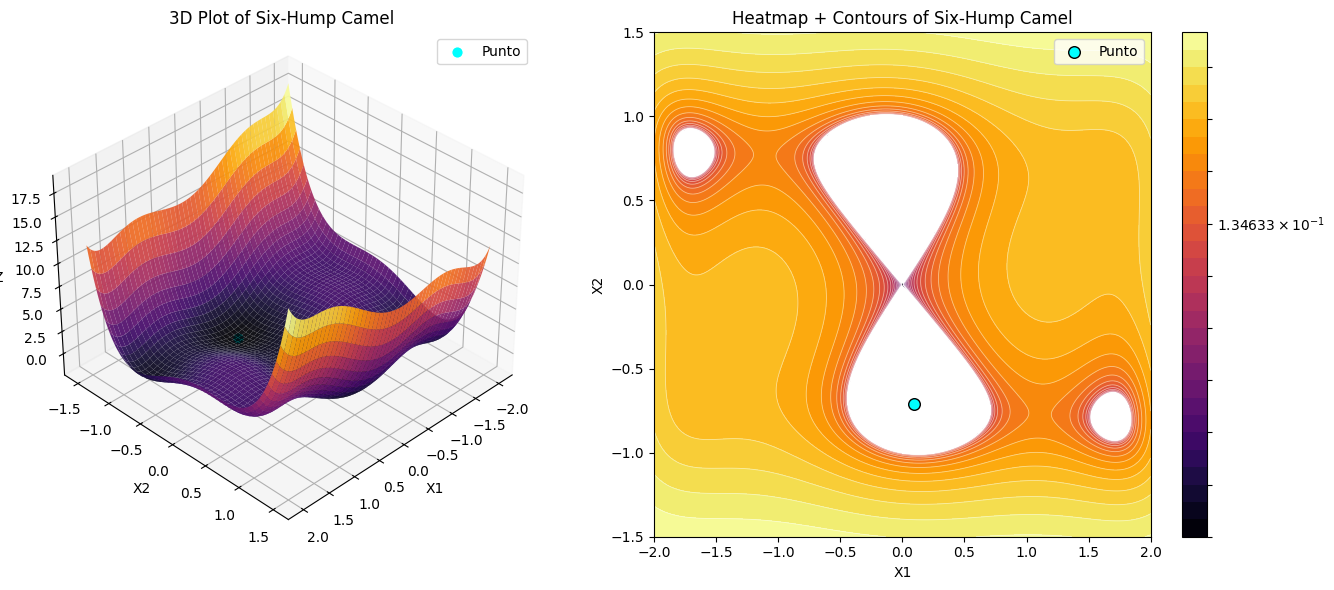

In [106]:
cfg = FUNCTION_VISUAL_CONFIGS["six_hump_camel"]
if cfg["active_in_data"]:
    plot_function_course_style(
        cfg["function"],
        cfg["x1_range"],
        cfg["x2_range"],
        title=cfg["display_name"],
        x1_point=cfg["point"][0],
        x2_point=cfg["point"][1],
        output_path=FIGURES_DIR / "six_hump_camel_mapa_calor_y_superficie.png",
    )
else:
    print(f"{cfg['display_name']} queda pendiente hasta que se generen sus datos experimentales.")


#### Resultados de Six-Hump Camel

A continuacion se organiza el analisis experimental de Six-Hump Camel con el mismo esquema usado en Rosenbrock, separando calidad de solucion, costo computacional y tablas resumen.

- histogramas de `valor_final` para medir cercania al optimo
- histogramas de `evaluaciones` para medir costo computacional
- tablas resumen para comparar comportamiento entre tamanos de muestra


##### Histogramas por tamano de muestra para Six-Hump Camel 2D

Para `Six-Hump Camel 2D` se muestran histogramas de `valor_final` y `evaluaciones` para  = 100`, `500` y `1000`, manteniendo el mismo criterio visual del resto del reporte.


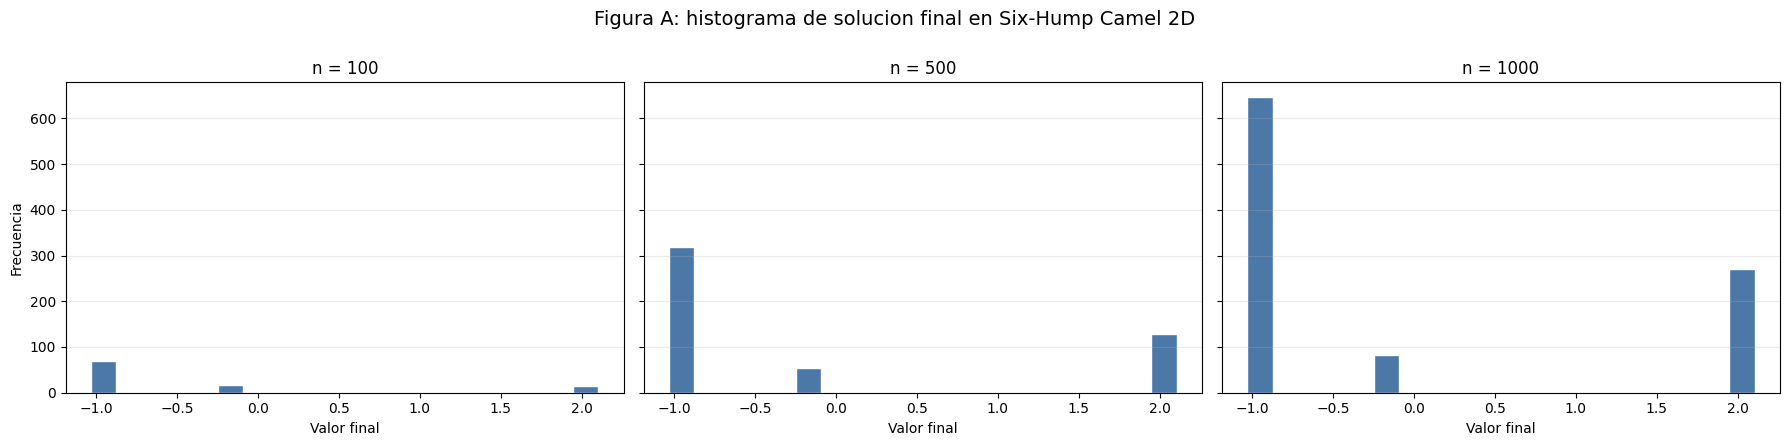

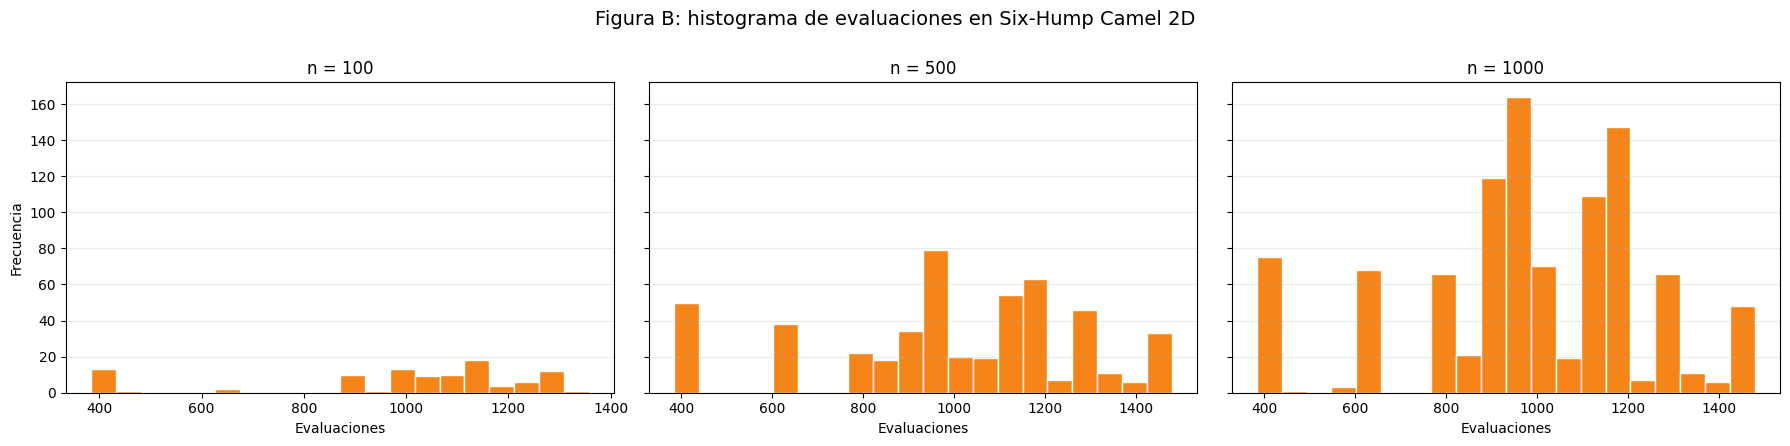

WindowsPath('c:/Carlos/Uni/Algortimos/trabajos/trabajo_1/trabajo_carlos/1. optimizacion_numerica/gradiente/datos/figuras/six_hump_camel_figura_b_histograma_evaluaciones_2d.png')

In [107]:
import importlib
import plot_utils
import report_utils
importlib.reload(plot_utils)
importlib.reload(report_utils)
from plot_utils import plot_evaluations_histogram, plot_final_value_histogram
from report_utils import prepare_function_runs, save_figure

six_hump_camel_runs_2d = prepare_function_runs(runs_df, run_files, "six_hump_camel", 2)
sample_sizes = [100, 500, 1000]
six_hump_camel_figures_dir = DATA_DIR / "figuras"
six_hump_camel_figures_dir.mkdir(parents=True, exist_ok=True)

fig_a_six_hump_camel_2d = plot_final_value_histogram(
    six_hump_camel_runs_2d,
    function_label="Six-Hump Camel",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_a_six_hump_camel_2d_path = six_hump_camel_figures_dir / "six_hump_camel_figura_a_histograma_solucion_final_2d.png"
fig_a_six_hump_camel_2d_path = save_figure(fig_a_six_hump_camel_2d, fig_a_six_hump_camel_2d_path)
plt.show()
fig_a_six_hump_camel_2d_path

fig_b_six_hump_camel_2d = plot_evaluations_histogram(
    six_hump_camel_runs_2d,
    function_label="Six-Hump Camel",
    dimension_label="2D",
    sample_sizes=sample_sizes,
)
fig_b_six_hump_camel_2d_path = six_hump_camel_figures_dir / "six_hump_camel_figura_b_histograma_evaluaciones_2d.png"
fig_b_six_hump_camel_2d_path = save_figure(fig_b_six_hump_camel_2d, fig_b_six_hump_camel_2d_path)
plt.show()
fig_b_six_hump_camel_2d_path


##### Tabla resumen de Six-Hump Camel 2D

La tabla siguiente resume `Mejor valor`, `Peor valor`, `Promedio`, `Desviacion estandar` y `Promedio de evaluaciones` para `Six-Hump Camel 2D`.


In [108]:
from report_utils import build_summary_table
tabla_resumen_six_hump_camel_2d = build_summary_table(
    summary_df,
    "six_hump_camel",
    2,
    dimension_label="2D",
    function_label="Six-Hump Camel",
)
tabla_resumen_six_hump_camel_2d


,Funcion,Dimension,Corridas,Mejor valor,Peor valor,Promedio,Desviacion estandar,Promedio de evaluaciones
0,Six-Hump Camel,2D,100,-1.031628,2.10425,-0.453857,1.075242,989.100
1,Six-Hump Camel,2D,500,-1.031628,2.10425,-0.136058,1.343751,996.392
2,Six-Hump Camel,2D,1000,-1.031628,2.10425,-0.114880,1.370816,986.337


##### Interpretacion de resultados para Six-Hump Camel

En `Six-Hump Camel 2D`, el descenso por gradiente muestra una **convergencia parcialmente adecuada**, aunque no completamente estable. El mejor valor encontrado es `-1.031628` en los tres tamanos de muestra, lo cual indica que el metodo si logra llegar a soluciones muy cercanas al optimo global conocido de la funcion. Sin embargo, este buen resultado no representa a todas las corridas, ya que tambien aparecen valores finales claramente peores, con un peor caso de `2.10425`.

La dispersion de los resultados es considerable. La desviacion estandar se mueve entre `1.0752` y `1.3708`, y aunque el promedio del valor final mejora al pasar de `-0.4539` en `n = 100` a aproximadamente `-0.115` en `n = 1000`, sigue quedando lejos del mejor minimo hallado. Esto sugiere que el algoritmo encuentra con cierta frecuencia soluciones aceptables, pero tambien cae en regiones menos favorables dependiendo del punto inicial o de la trayectoria seguida durante la optimizacion. En otras palabras, la funcion permite alcanzar el optimo, pero no de manera consistentemente robusta.

En cuanto al costo computacional, el comportamiento es **moderado y relativamente estable**, con un promedio de evaluaciones cercano a `990` en los tres casos (`989.1`, `996.4` y `986.3`). Esto es mejor que funciones mas costosas como Goldstein-Price o Schwefel, aunque sigue mostrando que muchas corridas requieren una cantidad similar de trabajo para terminar. Como `Six-Hump Camel` en este proyecto solo se estudia en `2D`, no hay comparacion con `3D`; aun asi, puede concluirse que el metodo tiene capacidad para encontrar soluciones muy buenas en esta funcion, pero con una dispersion suficientemente alta como para no considerarlo totalmente confiable en todas las corridas.
